## **IMPORTS**

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:
import random
import os
from dotenv import load_dotenv

import src.experiments.config as cfg_module
import src.env.station as st
import src.env.car as car_module
import src.env.society as sct
import src.experiments.simulation as sim_module
import src.experiments.simulation_greedy as sim_greedy
from src.experiments.run import define_agents
from src.metric.plots_metrics import *

pygame 2.6.1 (SDL 2.28.4, Python 3.12.0)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [3]:
load_dotenv()

ROOT_PATH = os.getenv("ROOT_PATH")
OUTPUT_DIR = 'outputs'
OUTPUT_PATH = f'{ROOT_PATH}/{OUTPUT_DIR}'
os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f'---> outputs logs in: {OUTPUT_PATH}')

---> outputs logs in: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs


## **UTILS**

### **CONFIG**

In [4]:
# --- CONFIG FUNCTION

def notebook_config(
    total_time=None,
    nb_car=None,
    nb_society=None,
    nb_station=None,
    base_car_behavior=None,
    station_strategy_noise=None,
    log_iter=None
):
    """
    Crée et configure un objet SimulationConfig
    pour les notebooks/tests.
    """

    config = cfg_module.SimulationConfig()

    # ------------------------------------------------ VISUALISATION
    config.set_VISUALIZE(False)

    # ------------------------------------------------ TEMPS
    if total_time is not None:
        config.set_TOTAL_TIME(total_time)

    if log_iter is not None:
        config.set_log_iter(log_iter)

    # ------------------------------------------------ AGENTS
    if nb_car is not None:

        if type(nb_car) is not int:
            raise TypeError(
                f"nb_car doit être un int, reçu : {type(nb_car).__name__}"
            )

        if nb_car <= 0:
            raise ValueError("nb_car doit être > 0")

        config.NB_CARS = nb_car

    if nb_society is not None:

        if type(nb_society) is not int:
            raise TypeError(
                f"nb_society doit être un int, reçu : {type(nb_society).__name__}"
            )

        if nb_society <= 0:
            raise ValueError("nb_society doit être > 0")

        config.NB_SOCIETIES = nb_society

    if nb_station is not None:

        if type(nb_station) is not int:
            raise TypeError(
                f"nb_station doit être un int, reçu : {type(nb_station).__name__}"
            )

        if nb_station <= 0:
            raise ValueError("nb_station doit être > 0")

        config.NB_STATIONS = nb_station

    # ------------------------------------------------ COMPORTEMENTS VOITURES
    if base_car_behavior is not None:

        required_keys = {
            'pres',
            'abs',
            'early',
            'late',
            'noise'
        }

        missing = required_keys - set(base_car_behavior.keys())

        if missing:
            raise ValueError(
                f"Clés manquantes dans base_car_behavior : {missing}"
            )

        total_prob = (
            base_car_behavior['pres']
            + base_car_behavior['abs']
            + base_car_behavior['early']
            + base_car_behavior['late']
        )

        if total_prob != 100:
            raise ValueError(
                f"La somme des probabilités doit valoir 100, reçu : {total_prob}"
            )

        config.BASE_CANCEL_PROB = base_car_behavior.copy()

    # ------------------------------------------------ BRUIT STRATÉGIE STATION
    if station_strategy_noise is not None:

        if not isinstance(station_strategy_noise, (int, float)):
            raise TypeError(
                "station_strategy_noise doit être numérique"
            )

        if station_strategy_noise < 0:
            raise ValueError(
                "station_strategy_noise doit être >= 0"
            )

        config.STRATEGY_NOISE = float(station_strategy_noise)

    return config

In [5]:
# --- EXAMPLE

total_time = 12 * 24 * 1  # une journée
log_iter = 12

nb_car = 50
nb_society = 4
nb_station = 40

strategy_noise = 0.5  # variation proportionnelle ±50%

base_car_behavior = {
    'pres': 75,     # présent et honore la réservation
    'abs': 10,      # no-show complet
    'early': 9,     # annulation anticipée (> 2h avant)
    'late': 6,      # annulation tardive (< 2h avant)
    'noise': 0.15
}

c = notebook_config(total_time=total_time, nb_car=nb_car, nb_society=nb_society,
                nb_station=nb_station, base_car_behavior=base_car_behavior,
                station_strategy_noise=strategy_noise, log_iter=log_iter)

slot_h = c.SLOT_DURATION / 60
dist_slot = c.CAR_SPEED          # m/slot
autonomy_mean = c.CAR_AUTONOMY_PARAMS_KM['mean']
conso = c.ENERGY_CONSUMPTION['quantity_kW'] / c.ENERGY_CONSUMPTION['distance_unit_m']
delta_soc = dist_slot * conso / (c.ENERGY_CONSUMPTION['quantity_kW'] * autonomy_mean / 100)

print(f"Grille            : {c.C_GRID/1e3:.1f} km × {c.C_GRID/1e3:.1f} km")
print(f"Vitesse           : {c.CAR_SPEED} m/slot  ({c.CAR_SPEED/1000/slot_h:.0f} km/h)")
print(f"ΔSoC / slot       : {delta_soc:.5f}  ({1/delta_soc:.0f} slots pour vider)")
print(f"Autonomie moy.    : {autonomy_mean} km")
print(f"Distance max grille traversée avec soc=0.10 : {0.10*autonomy_mean:.0f} km >> {c.C_GRID/1e3:.1f} km ✓")


Grille            : 3.0 km × 3.0 km
Vitesse           : 4167.0 m/slot  (50 km/h)
ΔSoC / slot       : 0.01042  (96 slots pour vider)
Autonomie moy.    : 400 km
Distance max grille traversée avec soc=0.10 : 40 km >> 3.0 km ✓


### **CHARTS**

#### *Demand Satisfaction*

In [6]:
def plot_exact_needs_comparison(exact_values, needs_values, labels, colors,
                                scenario_name, nb_car):

    # Création des graphiques côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Graphique Exact --------
    bars1 = axes[0].bar(labels, exact_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Exact Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[0].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[0].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Graphique Needs --------
    bars2 = axes[1].bar(labels, needs_values, color=colors, alpha=0.7)
    

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Needs Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[1].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[1].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Travel & Waiting*

In [7]:
def plot_travel_waiting_comparison(travel_values, waiting_values, labels, colors,
                                scenario_name, nb_car):

    # Création des subplots
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Travel Distance --------
    bars1 = axes[0].bar(labels, travel_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Travel Distance (km)', fontweight='bold')
    axes[0].set_ylabel('Distance (km)')
    axes[0].set_ylim(top = 1.15 * max(travel_values))

    # Valeurs sur les barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Waiting Time --------
    bars2 = axes[1].bar(labels, waiting_values, color=colors, alpha=0.7)

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Waiting Time (min)', fontweight='bold')
    axes[1].set_ylabel('Time (min)')
    if max(waiting_values) > 0.:
        axes[1].set_ylim(top = 1.15 * max(waiting_values))
    else:
        axes[1].set_ylim(bottom = 0. ,top = 5.)

    # Valeurs sur les barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Scalability*

In [8]:
def plot_mean_response_time_comparison(labels, colors, values, scenario_name, nb_car):

    fig, ax = plt.subplots(figsize=(6, 5))

    bars = ax.bar(labels, values, color=colors, alpha=0.8)

    scenario_tag = f"[{scenario_name[:3].upper()}@{nb_car}]"

    ax.set_title(
        f'{scenario_tag} Mean Response Time (ms)',
        fontweight='bold'
    )

    ax.set_ylabel('Response Time (ms)')

    if max(values) > 0:
        ax.set_ylim(0, 1.15 * max(values))

    # Affichage des valeurs
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01 * max(values),
            f'{height:.2f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Comparison*

In [9]:
def plot_metric_comparison(
    greedy_values,
    bramev_values,
    nb_car_list,
    ylabel,
    title,
    colors,
    scenario_name
):

    x = np.arange(len(nb_car_list))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    bars1 = ax.bar(
        x - width / 2,
        greedy_values,
        width,
        label='Greedy',
        color=colors[0],
        alpha=0.8
    )

    bars2 = ax.bar(
        x + width / 2,
        bramev_values,
        width,
        label='BRAMEV',
        color=colors[1],
        alpha=0.8
    )

    scenario_tag = f"[{scenario_name[:3].upper()}]"

    ax.set_title(
        f'{scenario_tag} {title}',
        fontweight='bold'
    )

    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(nb_car_list)
    ax.set_xlabel('Number of Cars')

    ax.legend()

    max_value = max(
        max(greedy_values),
        max(bramev_values)
    )

    if max_value > 0:
        ax.set_ylim(0, 1.15 * max_value)

    # Valeurs sur les barres
    for bars in [bars1, bars2]:

        for bar in bars:

            height = bar.get_height()

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.01 * max_value,
                f'{height:.2f}',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )

    plt.tight_layout()
    plt.show()
    plt.close()


# =========================================================
# 1. Exact Satisfaction
# =========================================================

def plot_exact_satisfaction(
    exact_satif_greedy_list,
    exact_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        exact_satif_greedy_list,
        exact_satif_bramev_list,
        nb_car_list,
        ylabel='Satisfaction (%)',
        title='Exact Satisfaction (%)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 2. Needs Satisfaction
# =========================================================

def plot_needs_satisfaction(
    needs_satif_greedy_list,
    needs_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        needs_satif_greedy_list,
        needs_satif_bramev_list,
        nb_car_list,
        ylabel='Satisfaction (%)',
        title='Needs Satisfaction (%)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 3. Mean Travel Distance
# =========================================================

def plot_mean_travel_distance(
    mean_travel_greedy_list,
    mean_travel_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_travel_greedy_list,
        mean_travel_bramev_list,
        nb_car_list,
        ylabel='Distance (km)',
        title='Mean Travel Distance (km)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 4. Mean Waiting Time
# =========================================================

def plot_mean_waiting_time(
    mean_waiting_greedy_list,
    mean_waiting_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_waiting_greedy_list,
        mean_waiting_bramev_list,
        nb_car_list,
        ylabel='Waiting Time (min)',
        title='Mean Waiting Time (min)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 5. Mean Response Time
# =========================================================

def plot_mean_response_time(
    mean_response_greedy_list,
    mean_response_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_response_greedy_list,
        mean_response_bramev_list,
        nb_car_list,
        ylabel='Response Time (ms)',
        title='Mean Response Time (ms)',
        colors=colors,
        scenario_name=scenario_name
    )
    

## **EXPERIMENTS**

### **GLOBAL CONFIG**

In [10]:
SCENARIO = 'pessimistic'

BASE_CAR_BEHAVIOR = {
    'pres': 40,     # présent et honore la réservation
    'abs': 20,      # no-show complet
    'early': 35,     # annulation anticipée (> 2h avant)
    'late': 5,      # annulation tardive (< 2h avant)
    'noise': 0.05
}

In [11]:
OUTPUT_FOLDER_PATH = f'{OUTPUT_PATH}/{SCENARIO}'
os.makedirs(OUTPUT_FOLDER_PATH, exist_ok=True)

print(f'Scenario outputs folders in folder: {OUTPUT_FOLDER_PATH}')

Scenario outputs folders in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/pessimistic


In [12]:
TOTAL_TIME = 12 * 24 * 5  # 5 jours
LOG_ITER = 12             # 12 -> toutes les heures

NB_SOCIETY = 4
NB_STATION = 40

STRATEGY_NOISE = 0.5  # variation proportionnelle ±50%

In [13]:
nb_car_list = []

exact_satif_greedy_list, exact_satif_bramev_list = [], []
needs_satif_greedy_list, needs_satif_bramev_list = [], []
mean_travel_greedy_list, mean_travel_bramev_list = [], []
mean_waiting_greedy_list, mean_waiting_bramev_list = [], []
mean_response_greedy_list, mean_response_bramev_list = [], []

### **EVChargingManagement@50cars**

#### **CONFIG**

In [14]:
nb_car = 50
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [15]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/pessimistic/greedy/50cars


##### *Initialisation*

In [16]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [17]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-26 00:10:13.542 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-26 00:10:13.655 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-26 00:10:13.719 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-26 00:10:13.811 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-26 00:10:13.907 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-26 00:10:13.974 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-26 00:10:14.065 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-26 00:10:14.166 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-26 00:10:14.189 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-26 00:10:14.244 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-26 00:10:14.288 | IN

##### *Metrics*

In [18]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 0.00 kWh
  Station 1: 15.18 kWh
  Station 2: 1.55 kWh
  Station 3: 0.00 kWh
  Station 4: 1.45 kWh
  Station 5: 87.18 kWh
  Station 6: 2.27 kWh
  Station 7: 4.90 kWh
  Station 8: 4.72 kWh
  Station 9: 0.00 kWh
  Station 10: 1.75 kWh
  Station 11: 1.87 kWh
  Station 12: 5.23 kWh
  Station 13: 3.65 kWh
  Station 14: 0.00 kWh
  Station 15: 1.73 kWh
  Station 16: 8.54 kWh
  Station 17: 30.42 kWh
  Station 18: 10.37 kWh
  Station 19: 56.65 kWh
  Station 20: 7.83 kWh
  Station 21: 16.88 kWh
  Station 22: 0.00 kWh
  Station 23: 2.17 kWh
  Station 24: 2.16 kWh
  Station 25: 50.62 kWh
  Station 26: 87.42 kWh
  Station 27: 0.00 kWh
  Station 28: 22.06 kWh
  Station 29: 14.42 kWh
  Station 30: 88.03 kWh
  Station 31: 1.88 kWh
  Station 32: 1.20 kWh
  Station 33: 11.50 kWh
  Station 34: 12.93 kWh
  Station 35: 1.60 kWh
  Station 36: 0.00 kWh
  Station 37: 0.00 kWh
  Station 38: 0.00 kWh
  Station 39: 4.89 kWh

--- User Requ

In [19]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

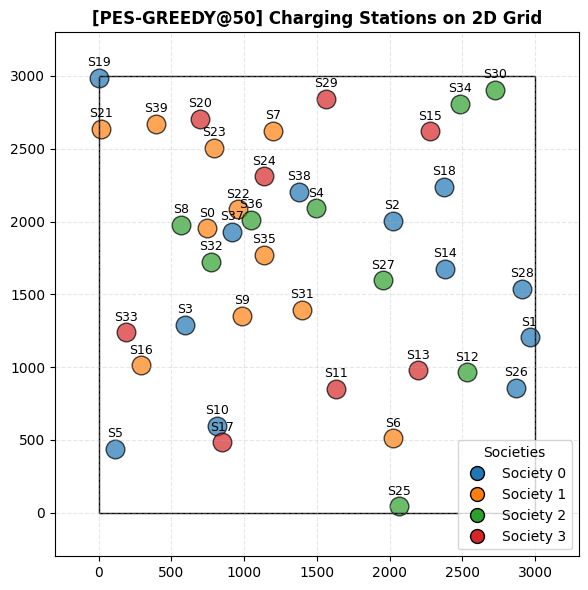

In [20]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=300)

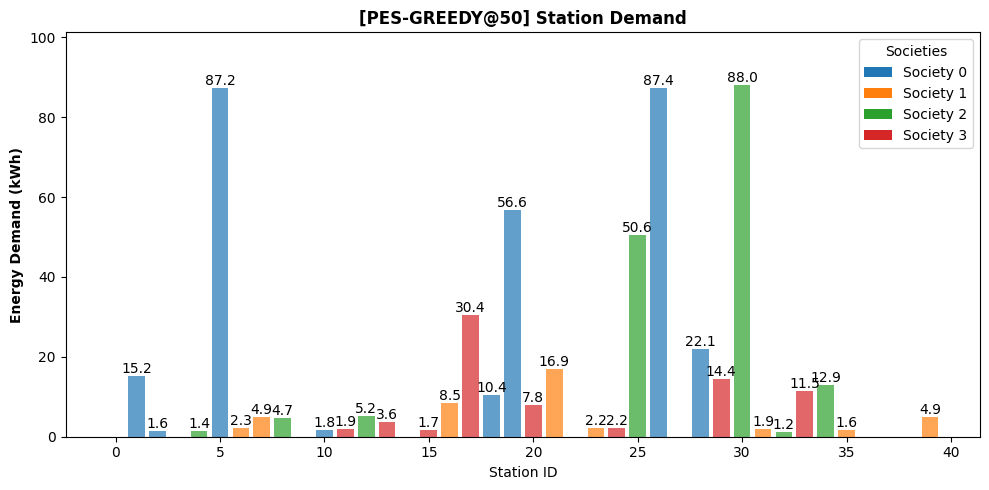

In [21]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

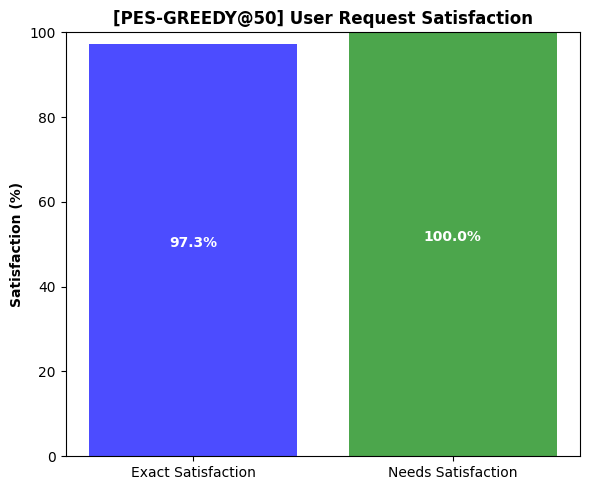

In [22]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

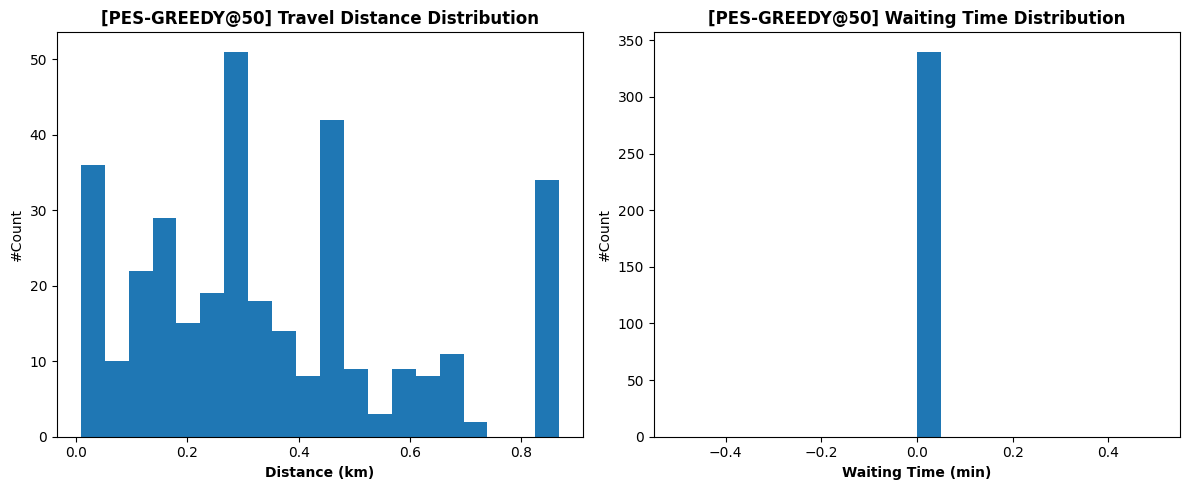

In [23]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

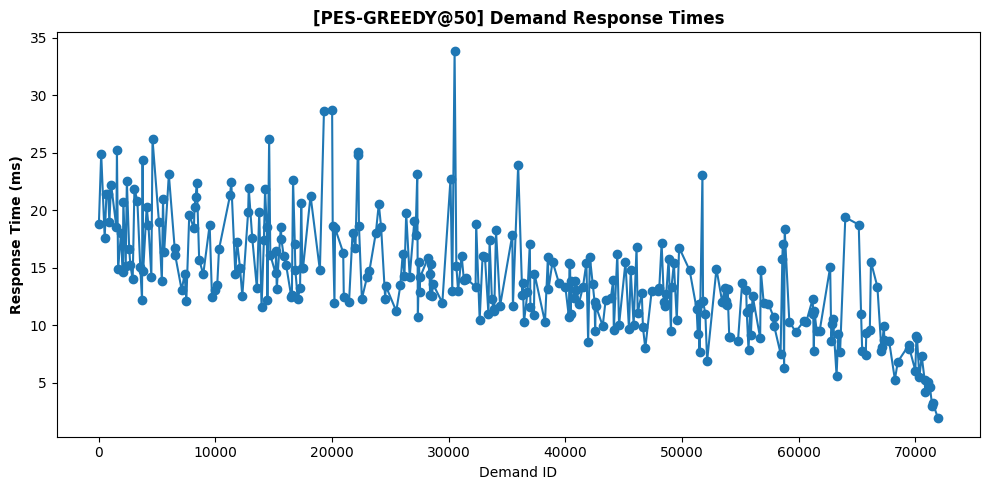

In [24]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

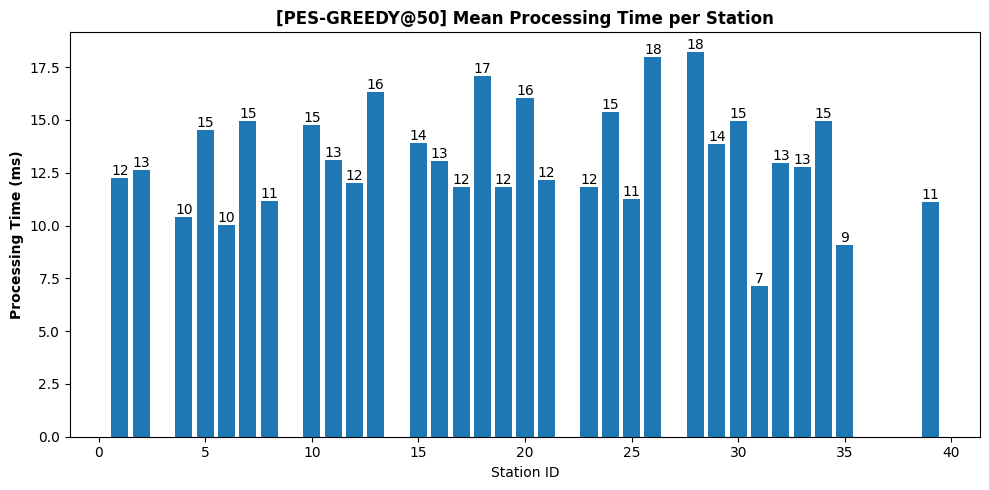

In [25]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [26]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/pessimistic/bramev/50cars


##### *Initialisation*

In [27]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [28]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-26 00:10:19.906 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-26 00:10:20.750 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-26 00:10:21.372 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-26 00:10:22.033 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-26 00:10:22.342 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-26 00:10:22.816 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-26 00:10:22.978 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-26 00:10:23.527 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-26 00:10:24.706 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-26 00:10:25.168 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-26 00:10:25.634 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [29]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 4.91 kWh
  Station 1: 0.00 kWh
  Station 2: 13.07 kWh
  Station 3: 22.52 kWh
  Station 4: 24.65 kWh
  Station 5: 29.01 kWh
  Station 6: 14.55 kWh
  Station 7: 10.82 kWh
  Station 8: 5.20 kWh
  Station 9: 17.56 kWh
  Station 10: 7.23 kWh
  Station 11: 5.07 kWh
  Station 12: 21.69 kWh
  Station 13: 12.00 kWh
  Station 14: 2.54 kWh
  Station 15: 3.12 kWh
  Station 16: 5.07 kWh
  Station 17: 15.26 kWh
  Station 18: 1.81 kWh
  Station 19: 4.10 kWh
  Station 20: 12.05 kWh
  Station 21: 61.98 kWh
  Station 22: 16.73 kWh
  Station 23: 3.23 kWh
  Station 24: 2.07 kWh
  Station 25: 40.28 kWh
  Station 26: 11.06 kWh
  Station 27: 60.50 kWh
  Station 28: 4.06 kWh
  Station 29: 2.13 kWh
  Station 30: 3.38 kWh
  Station 31: 3.82 kWh
  Station 32: 10.84 kWh
  Station 33: 10.65 kWh
  Station 34: 3.10 kWh
  Station 35: 10.10 kWh
  Station 36: 20.76 kWh
  Station 37: 5.98 kWh
  Station 38: 6.32 kWh
  Station 39: 56.21 kWh

--- U

In [30]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

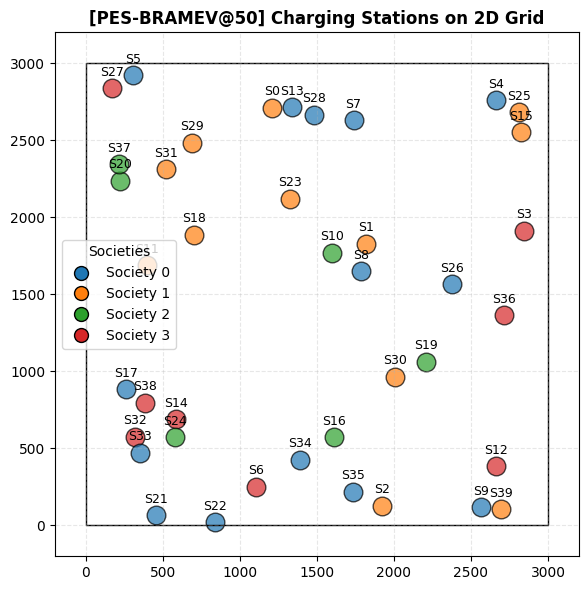

In [31]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

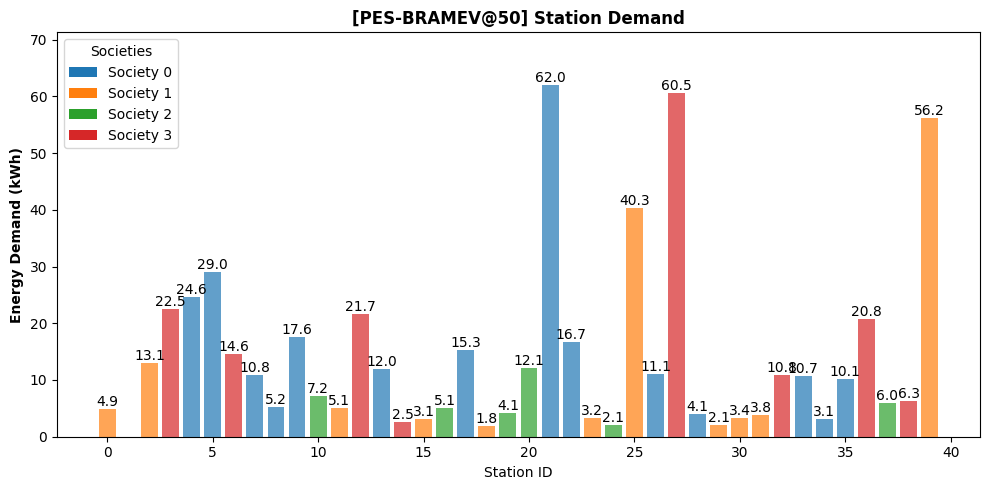

In [32]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

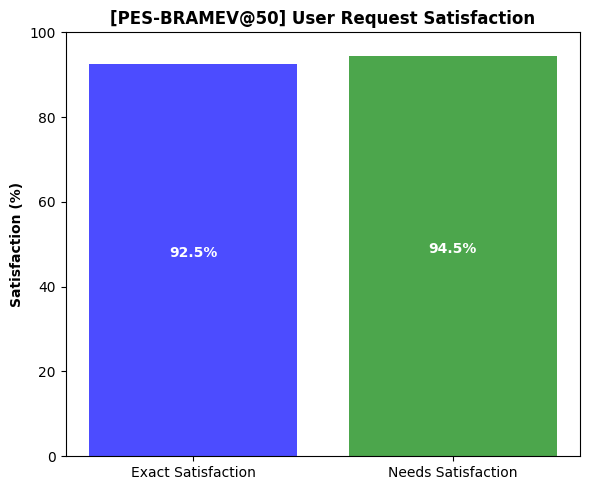

In [33]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

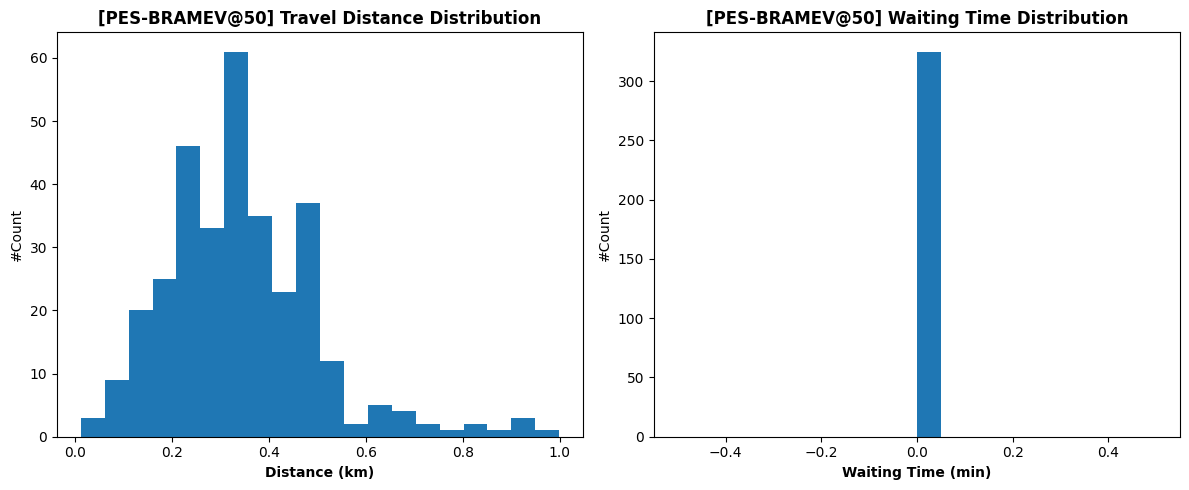

In [34]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

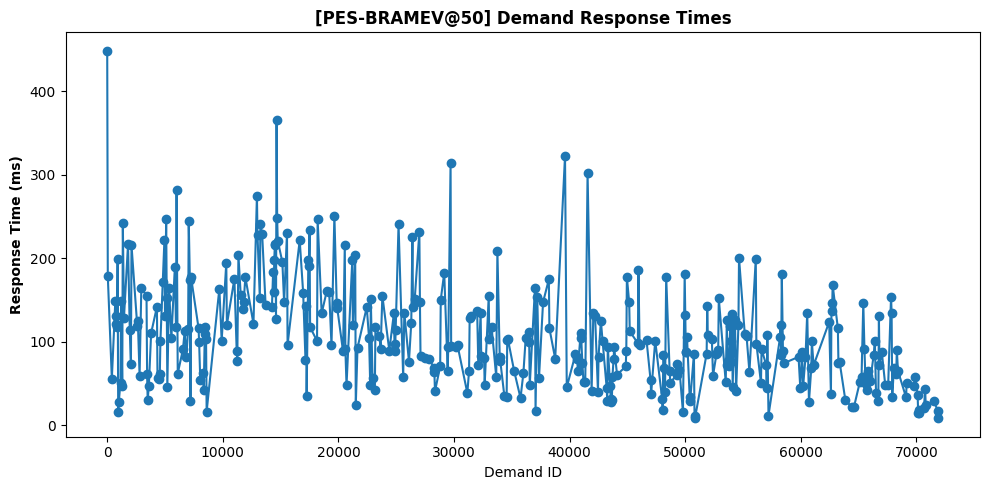

In [35]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

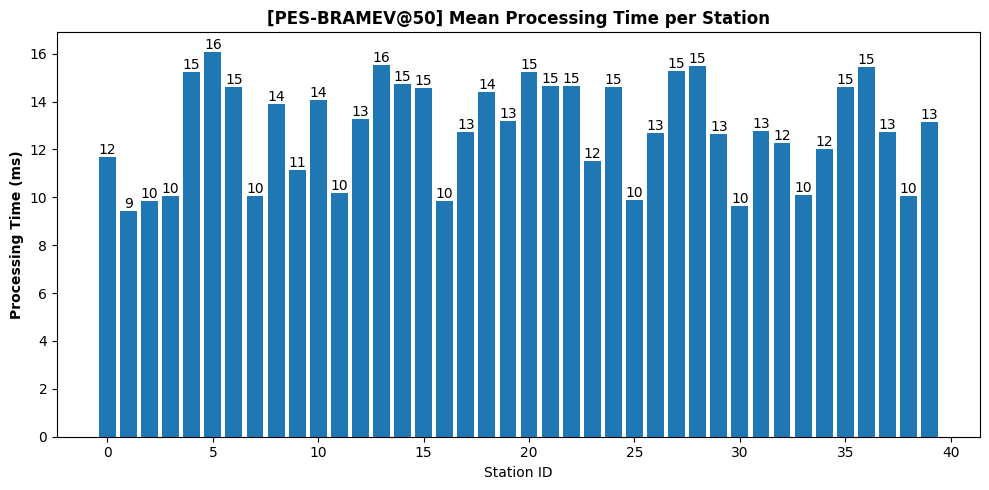

In [36]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [37]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

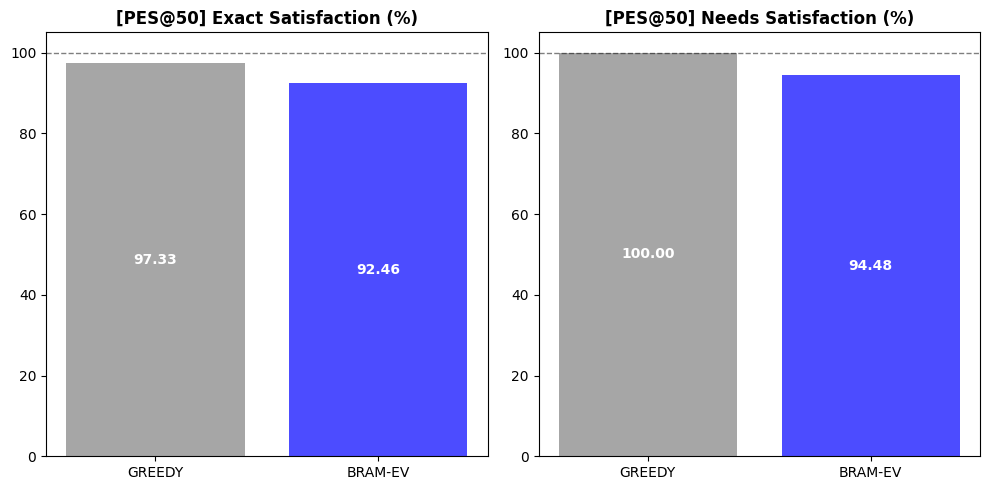

In [38]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

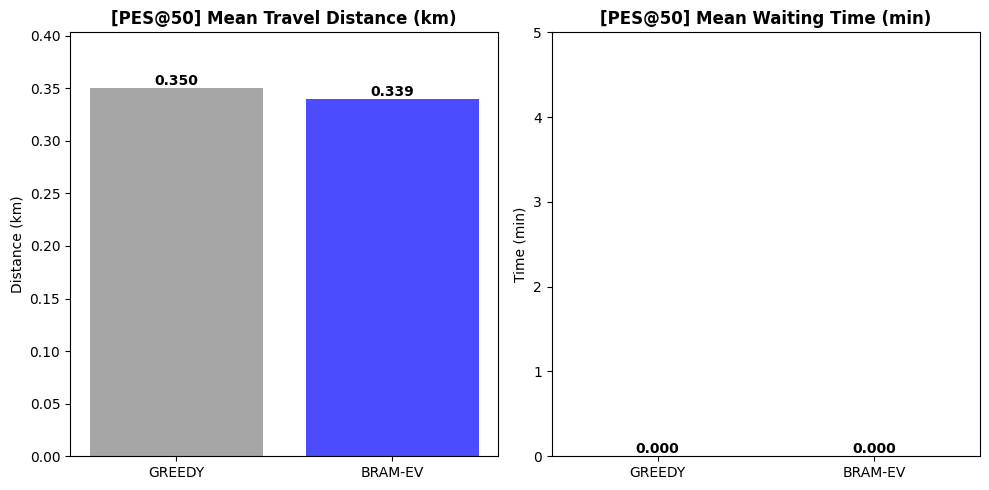

In [39]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

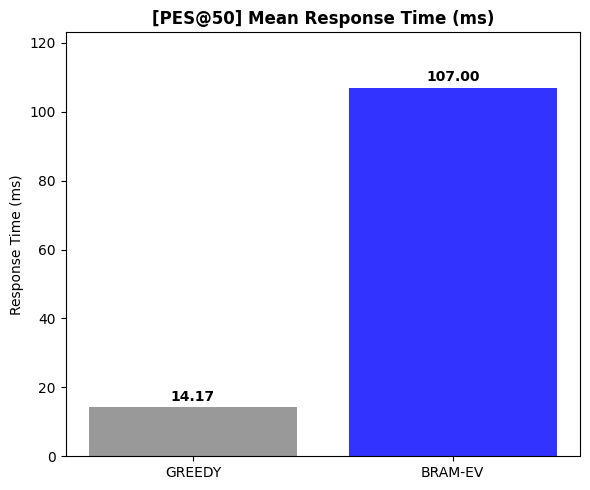

In [40]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@100cars**

#### **CONFIG**

In [41]:
nb_car = 100
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [42]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/pessimistic/greedy/100cars


##### *Initialisation*

In [43]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [44]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-26 00:11:13.754 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-26 00:11:13.902 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-26 00:11:13.988 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-26 00:11:14.088 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-26 00:11:14.206 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-26 00:11:14.313 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-26 00:11:14.444 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-26 00:11:14.605 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-26 00:11:14.697 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-26 00:11:14.781 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-26 00:11:14.867 | IN

##### *Metrics*

In [45]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 154.32 kWh
  Station 1: 8.60 kWh
  Station 2: 6.00 kWh
  Station 3: 46.53 kWh
  Station 4: 0.00 kWh
  Station 5: 37.36 kWh
  Station 6: 1.83 kWh
  Station 7: 0.00 kWh
  Station 8: 2.92 kWh
  Station 9: 1.67 kWh
  Station 10: 28.37 kWh
  Station 11: 6.97 kWh
  Station 12: 29.15 kWh
  Station 13: 4.26 kWh
  Station 14: 7.49 kWh
  Station 15: 26.72 kWh
  Station 16: 23.14 kWh
  Station 17: 6.23 kWh
  Station 18: 24.86 kWh
  Station 19: 5.50 kWh
  Station 20: 0.00 kWh
  Station 21: 6.02 kWh
  Station 22: 3.55 kWh
  Station 23: 151.56 kWh
  Station 24: 7.64 kWh
  Station 25: 64.33 kWh
  Station 26: 24.48 kWh
  Station 27: 1.73 kWh
  Station 28: 7.03 kWh
  Station 29: 0.00 kWh
  Station 30: 152.07 kWh
  Station 31: 29.77 kWh
  Station 32: 1.60 kWh
  Station 33: 5.17 kWh
  Station 34: 1.50 kWh
  Station 35: 64.75 kWh
  Station 36: 3.58 kWh
  Station 37: 5.76 kWh
  Station 38: 144.23 kWh
  Station 39: 1.33 kWh

--- Use

In [46]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

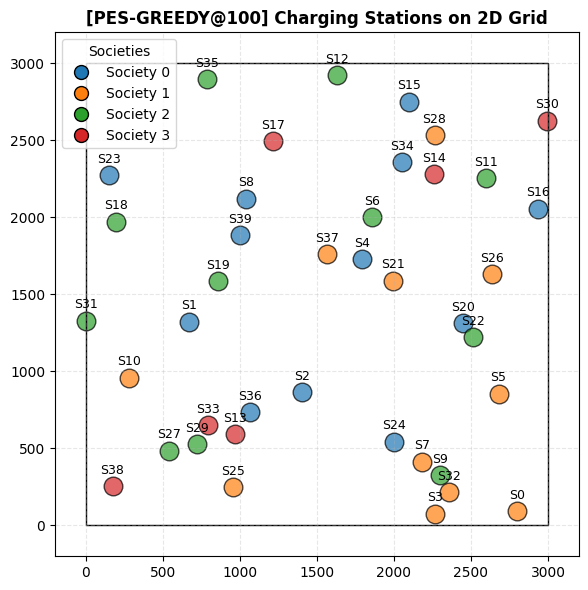

In [47]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

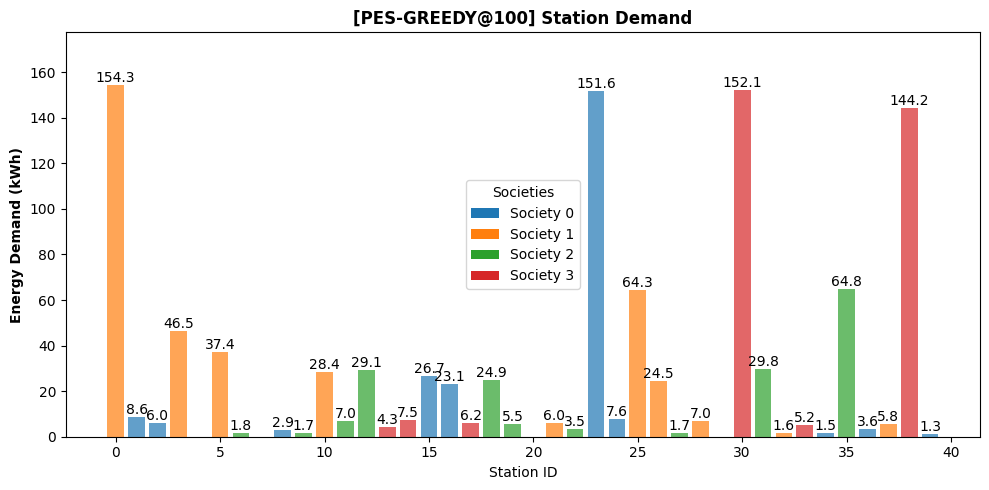

In [48]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

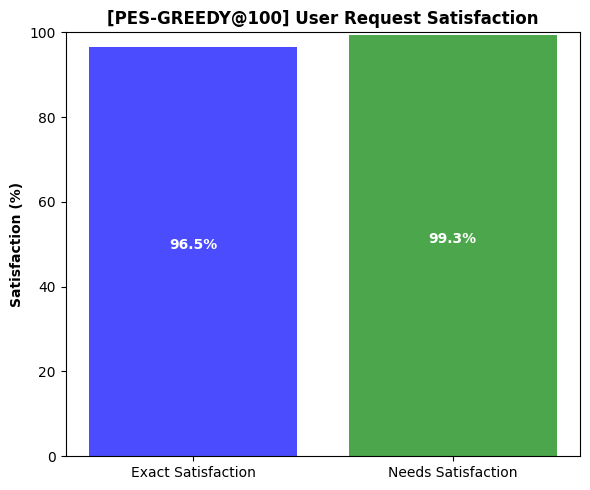

In [49]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

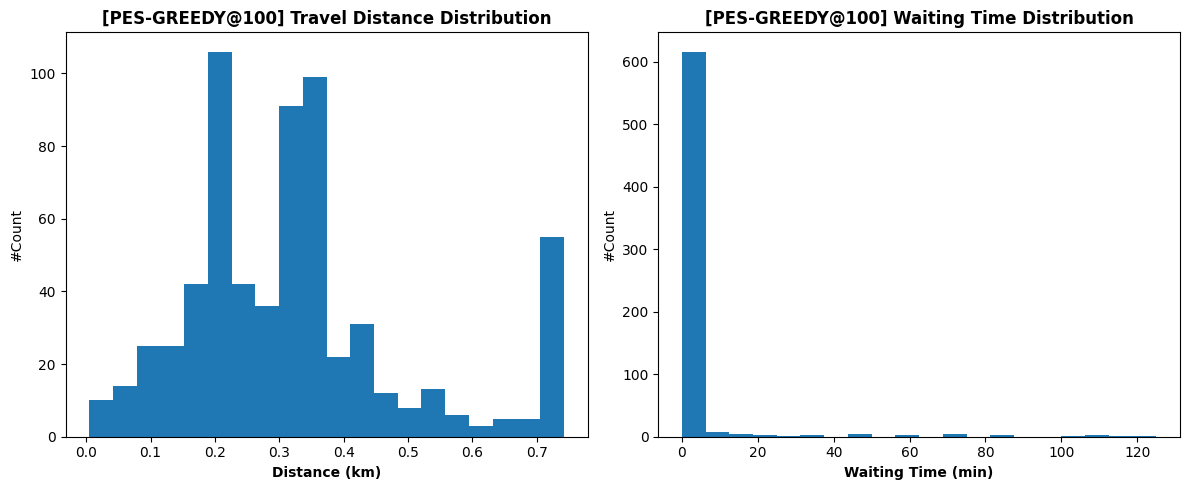

In [50]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

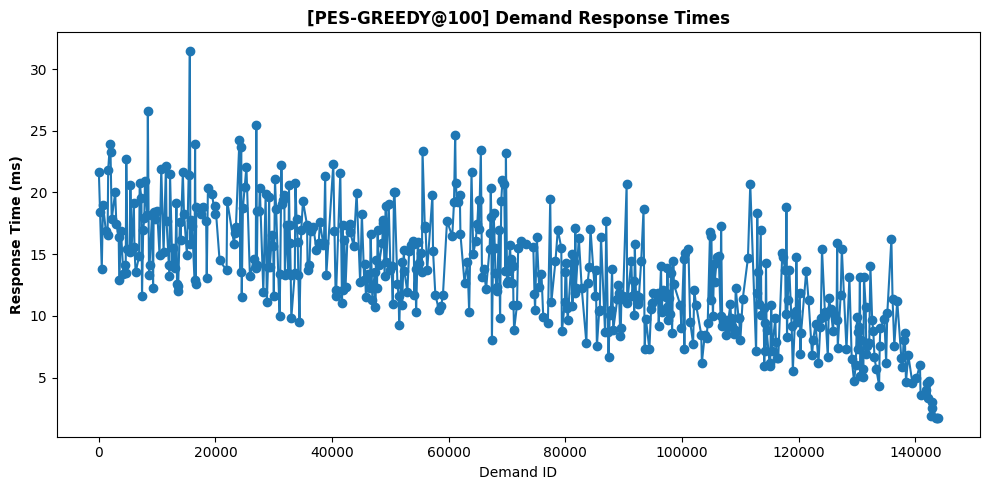

In [51]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

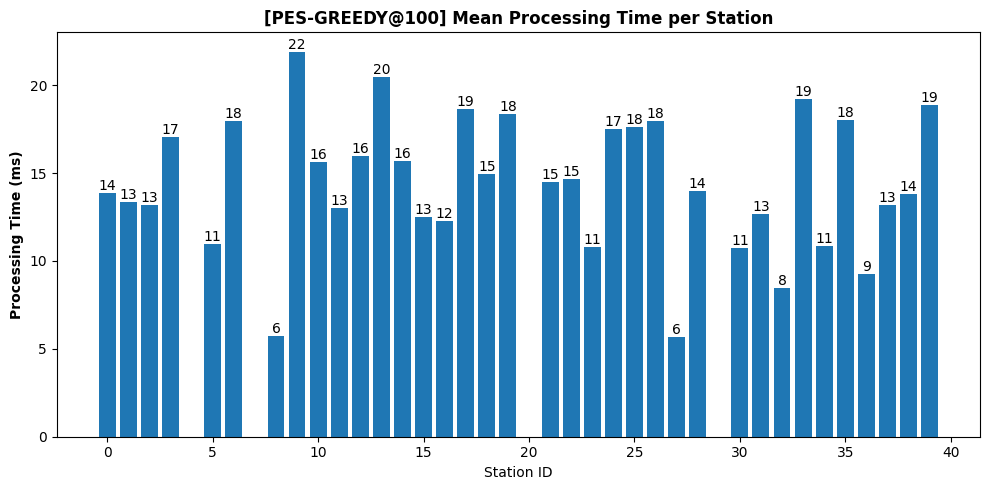

In [52]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [53]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/pessimistic/bramev/100cars


##### *Initialisation*

In [54]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [55]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-26 00:11:27.879 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-26 00:11:29.408 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-26 00:11:30.890 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-26 00:11:31.503 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-26 00:11:32.926 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-26 00:11:33.959 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-26 00:11:34.418 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-26 00:11:35.464 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-26 00:11:35.782 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-26 00:11:36.564 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-26 00:11:37.399 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [56]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 125.21 kWh
  Station 1: 35.10 kWh
  Station 2: 1.73 kWh
  Station 3: 75.72 kWh
  Station 4: 3.83 kWh
  Station 5: 0.00 kWh
  Station 6: 28.36 kWh
  Station 7: 43.27 kWh
  Station 8: 3.45 kWh
  Station 9: 34.19 kWh
  Station 10: 1.67 kWh
  Station 11: 134.78 kWh
  Station 12: 21.43 kWh
  Station 13: 19.01 kWh
  Station 14: 37.73 kWh
  Station 15: 0.00 kWh
  Station 16: 45.73 kWh
  Station 17: 14.63 kWh
  Station 18: 9.13 kWh
  Station 19: 1.83 kWh
  Station 20: 15.38 kWh
  Station 21: 4.25 kWh
  Station 22: 10.83 kWh
  Station 23: 0.00 kWh
  Station 24: 29.23 kWh
  Station 25: 9.43 kWh
  Station 26: 129.55 kWh
  Station 27: 30.25 kWh
  Station 28: 0.80 kWh
  Station 29: 14.37 kWh
  Station 30: 6.83 kWh
  Station 31: 2.27 kWh
  Station 32: 1.33 kWh
  Station 33: 0.00 kWh
  Station 34: 1.93 kWh
  Station 35: 53.88 kWh
  Station 36: 26.13 kWh
  Station 37: 1.63 kWh
  Station 38: 1.73 kWh
  Station 39: 149.94 kWh

-

In [57]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

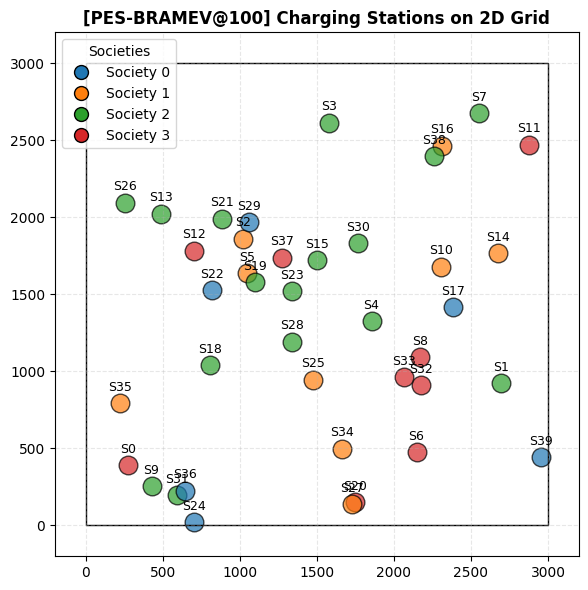

In [58]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

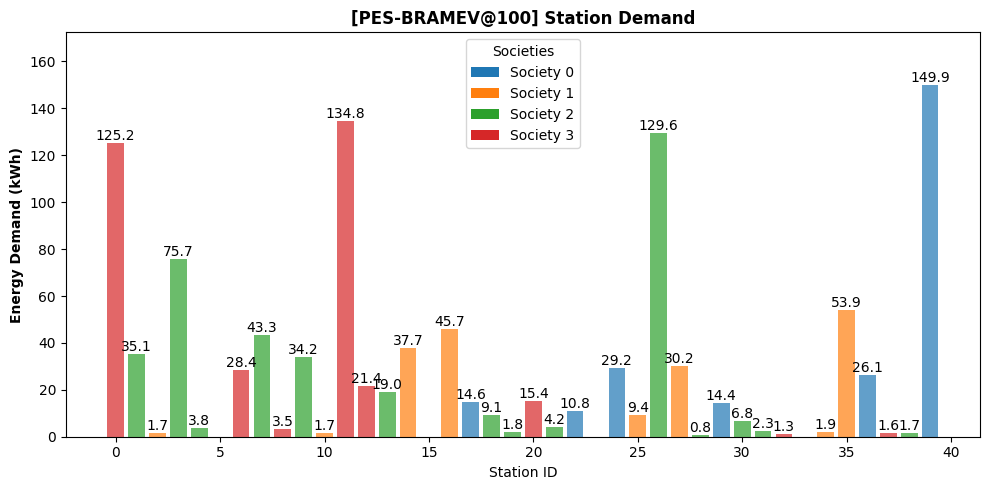

In [59]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

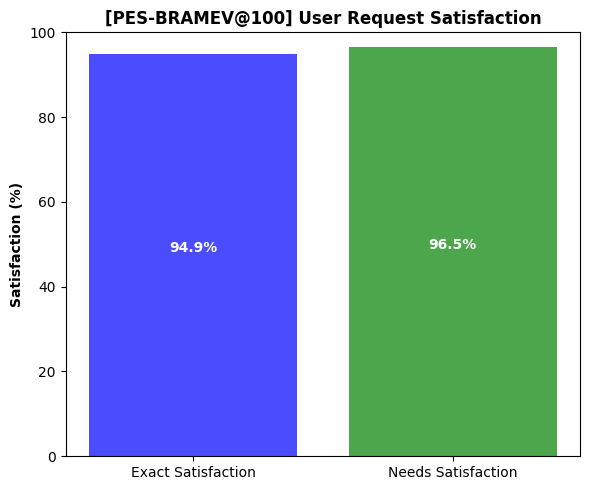

In [60]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

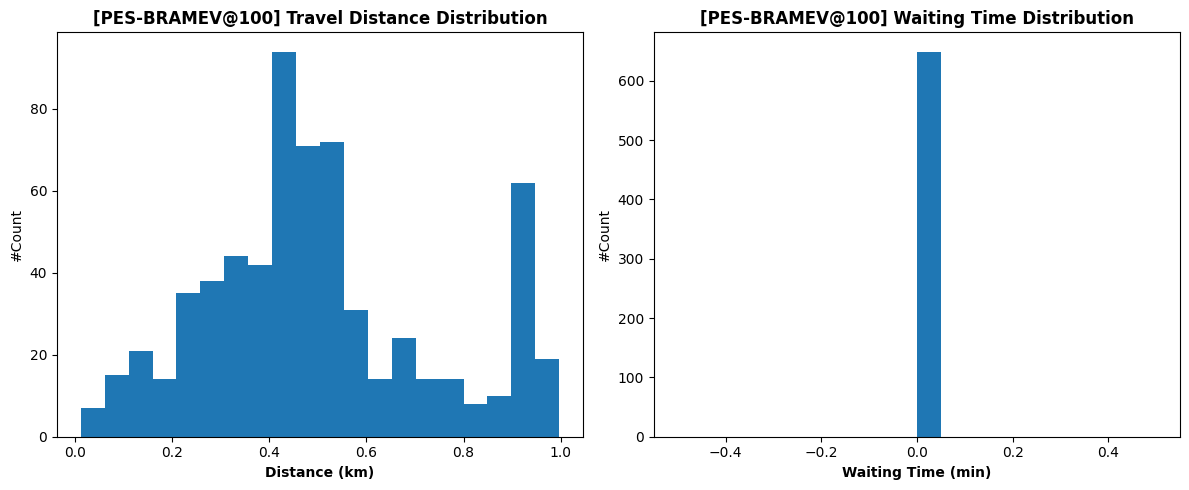

In [61]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

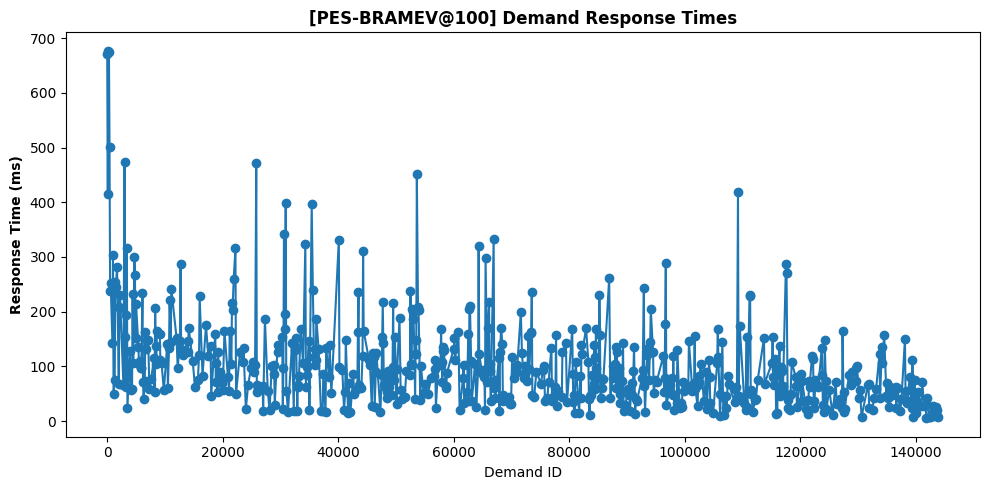

In [62]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

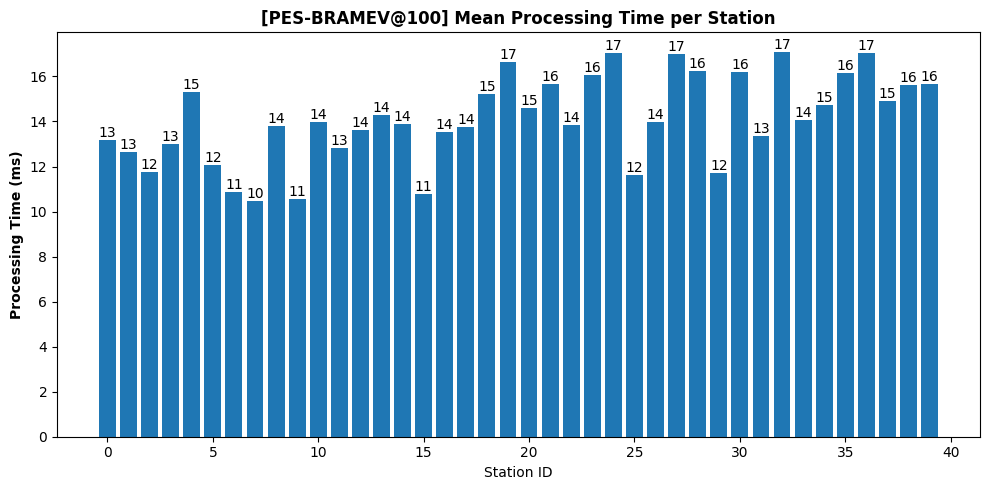

In [63]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [64]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

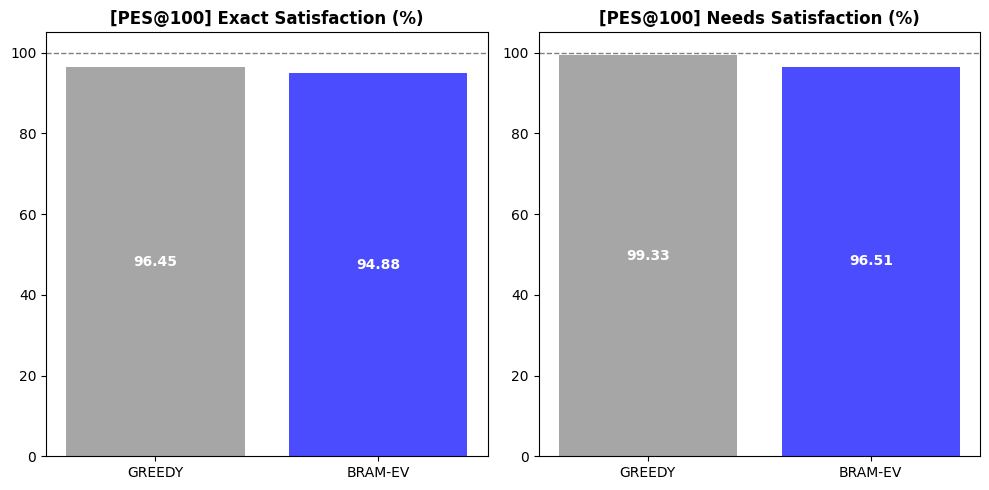

In [65]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

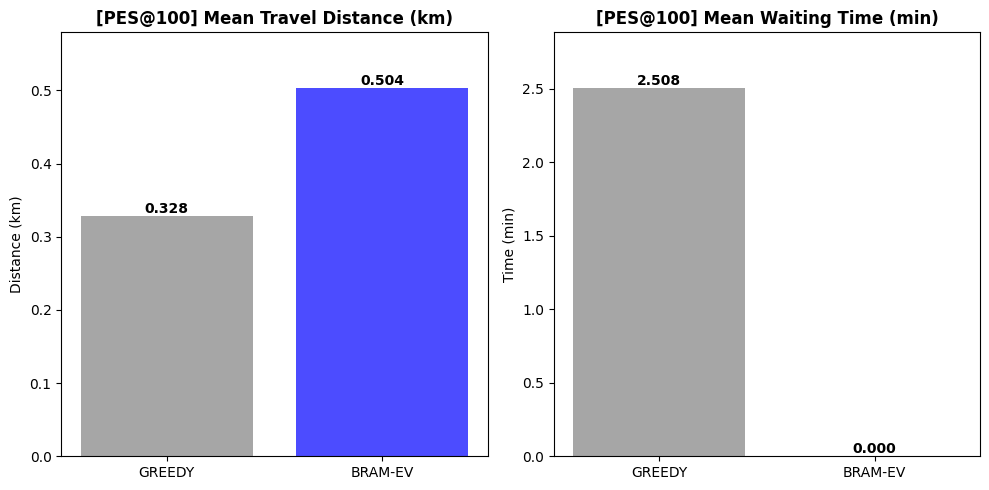

In [66]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

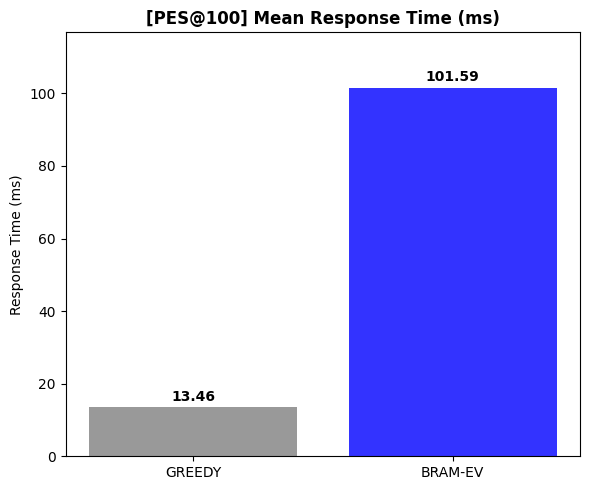

In [67]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@150cars**

#### **CONFIG**

In [68]:
nb_car = 150
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [69]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/pessimistic/greedy/150cars


##### *Initialisation*

In [70]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [71]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-26 00:12:31.765 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-26 00:12:32.023 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-26 00:12:32.187 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-26 00:12:32.337 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-26 00:12:32.505 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-26 00:12:32.668 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-26 00:12:32.859 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-26 00:12:33.071 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-26 00:12:33.277 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-26 00:12:33.472 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-26 00:12:33.563 | IN

##### *Metrics*

In [72]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 4.51 kWh
  Station 1: 4.48 kWh
  Station 2: 60.31 kWh
  Station 3: 119.49 kWh
  Station 4: 222.88 kWh
  Station 5: 6.95 kWh
  Station 6: 22.06 kWh
  Station 7: 5.71 kWh
  Station 8: 221.23 kWh
  Station 9: 10.48 kWh
  Station 10: 7.12 kWh
  Station 11: 97.72 kWh
  Station 12: 31.90 kWh
  Station 13: 7.42 kWh
  Station 14: 7.20 kWh
  Station 15: 64.28 kWh
  Station 16: 12.87 kWh
  Station 17: 2.20 kWh
  Station 18: 226.09 kWh
  Station 19: 5.79 kWh
  Station 20: 5.33 kWh
  Station 21: 5.06 kWh
  Station 22: 39.13 kWh
  Station 23: 96.40 kWh
  Station 24: 42.23 kWh
  Station 25: 1.87 kWh
  Station 26: 35.61 kWh
  Station 27: 15.82 kWh
  Station 28: 231.26 kWh
  Station 29: 1.63 kWh
  Station 30: 0.00 kWh
  Station 31: 6.70 kWh
  Station 32: 1.73 kWh
  Station 33: 0.00 kWh
  Station 34: 0.47 kWh
  Station 35: 5.44 kWh
  Station 36: 4.12 kWh
  Station 37: 8.72 kWh
  Station 38: 12.55 kWh
  Station 39: 0.00 kWh

---

In [73]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

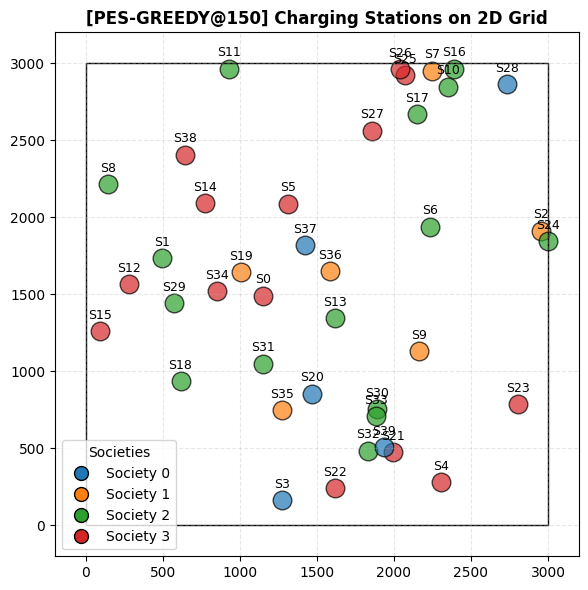

In [74]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

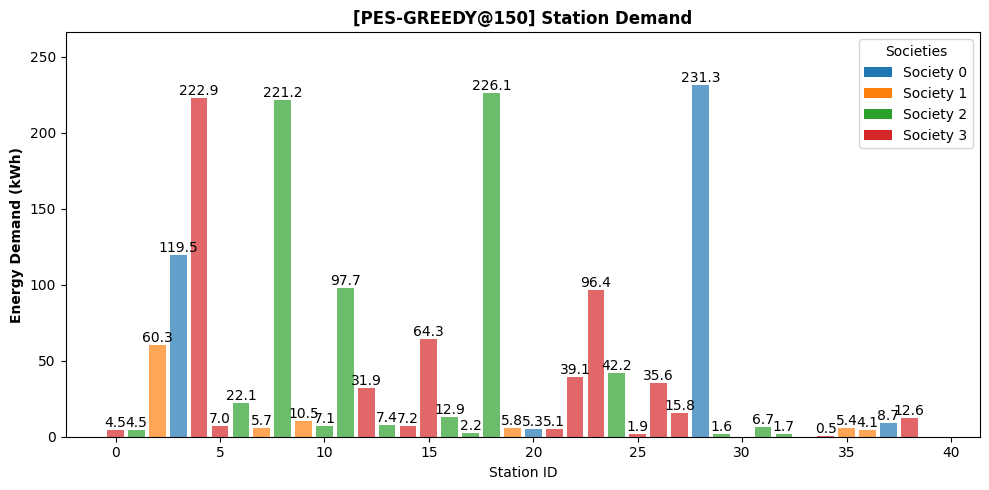

In [75]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

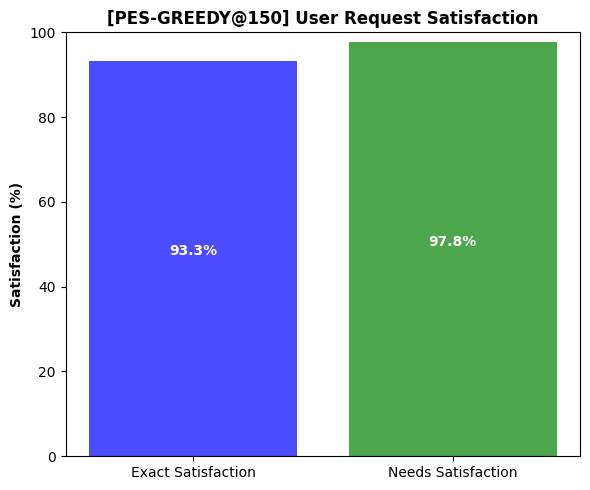

In [76]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

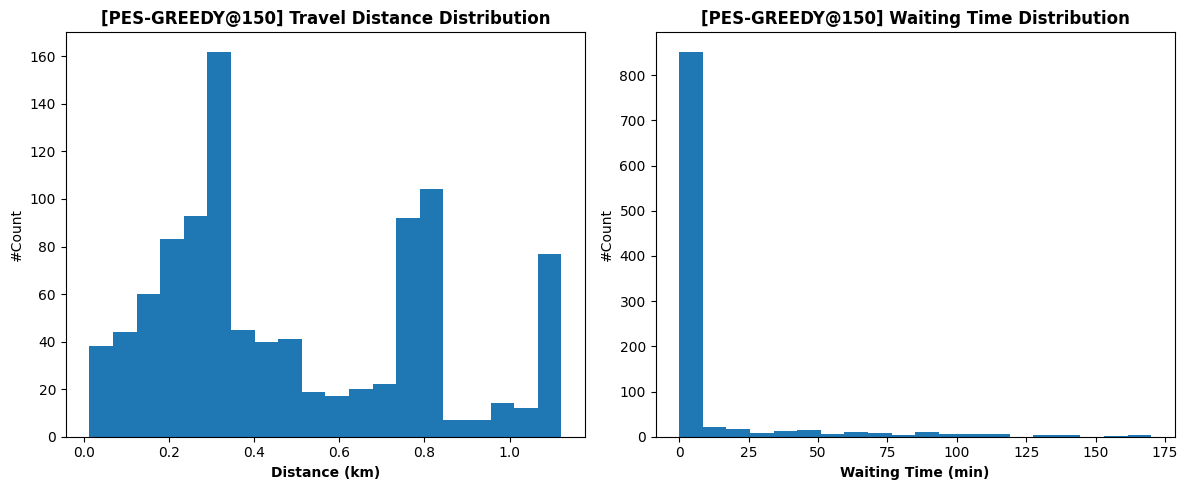

In [77]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

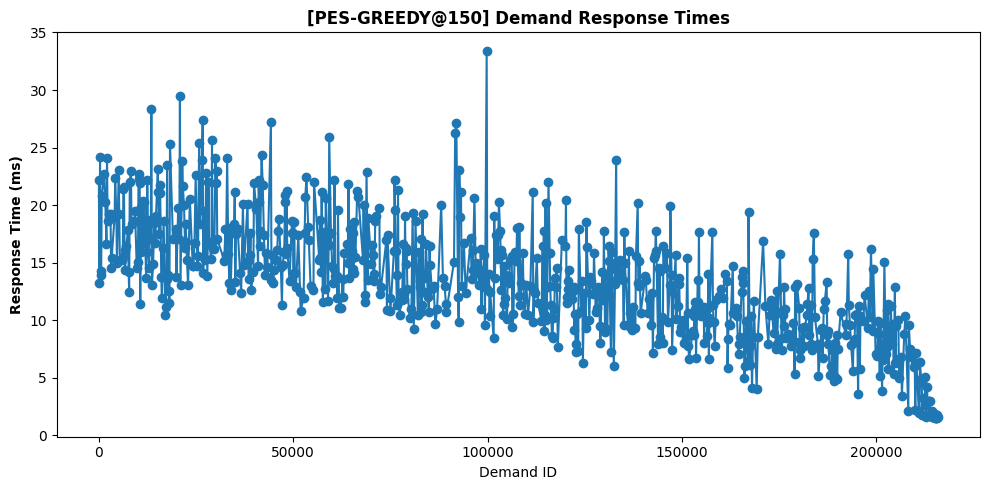

In [78]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

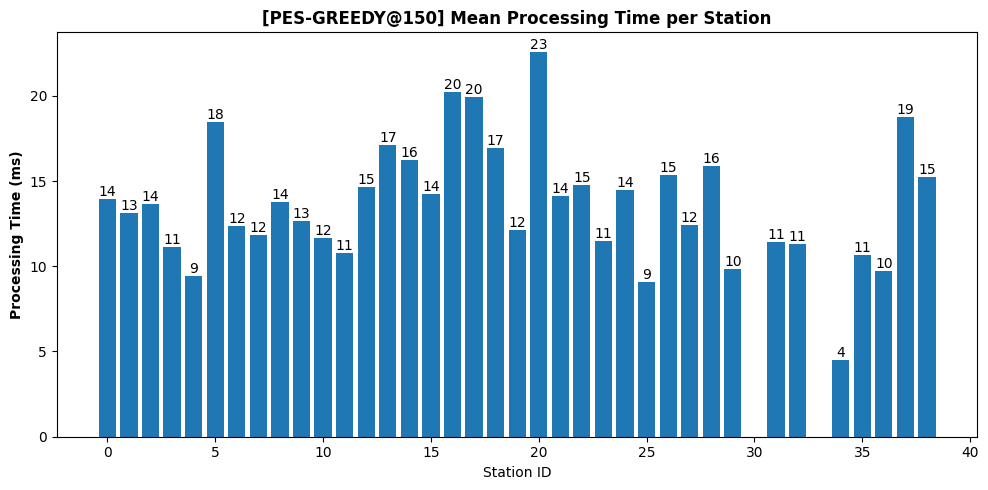

In [79]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [80]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/pessimistic/bramev/150cars


##### *Initialisation*

In [81]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [82]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-26 00:12:51.076 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-26 00:12:52.091 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-26 00:12:53.196 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-26 00:12:55.111 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-26 00:12:56.383 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-26 00:12:58.490 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-26 00:12:59.057 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-26 00:13:00.390 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-26 00:13:01.787 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-26 00:13:02.500 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-26 00:13:04.305 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [83]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 53.70 kWh
  Station 1: 23.00 kWh
  Station 2: 17.68 kWh
  Station 3: 33.00 kWh
  Station 4: 5.41 kWh
  Station 5: 19.22 kWh
  Station 6: 54.25 kWh
  Station 7: 42.08 kWh
  Station 8: 215.82 kWh
  Station 9: 63.84 kWh
  Station 10: 80.04 kWh
  Station 11: 6.95 kWh
  Station 12: 9.06 kWh
  Station 13: 45.28 kWh
  Station 14: 40.83 kWh
  Station 15: 5.80 kWh
  Station 16: 18.69 kWh
  Station 17: 99.36 kWh
  Station 18: 14.87 kWh
  Station 19: 56.54 kWh
  Station 20: 10.64 kWh
  Station 21: 2.17 kWh
  Station 22: 6.12 kWh
  Station 23: 2.25 kWh
  Station 24: 61.33 kWh
  Station 25: 153.77 kWh
  Station 26: 4.93 kWh
  Station 27: 38.29 kWh
  Station 28: 137.25 kWh
  Station 29: 138.44 kWh
  Station 30: 28.67 kWh
  Station 31: 7.22 kWh
  Station 32: 47.08 kWh
  Station 33: 11.46 kWh
  Station 34: 20.23 kWh
  Station 35: 1.79 kWh
  Station 36: 1.80 kWh
  Station 37: 40.81 kWh
  Station 38: 1.93 kWh
  Station 39: 38.10

In [84]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

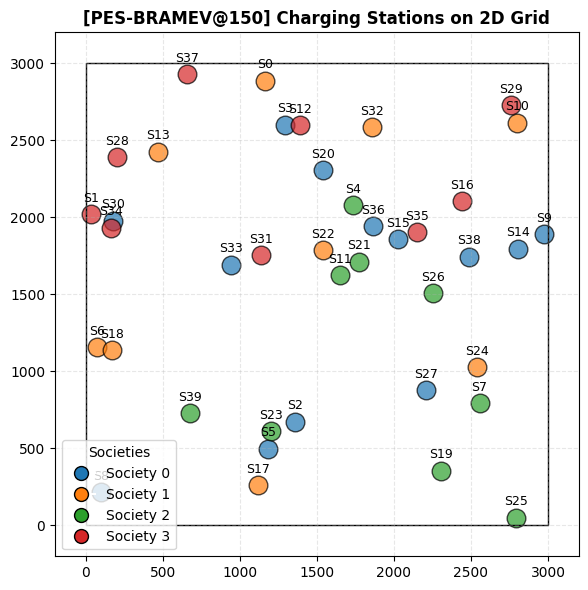

In [85]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

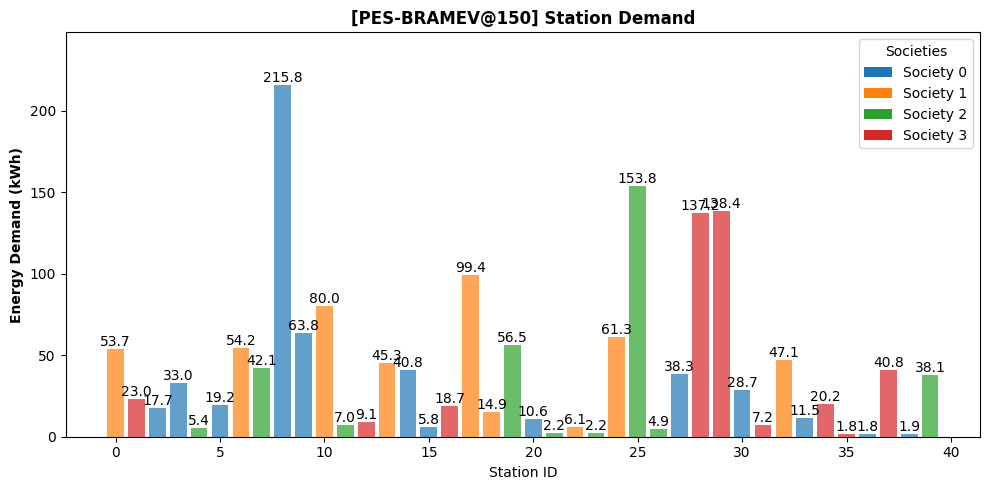

In [86]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

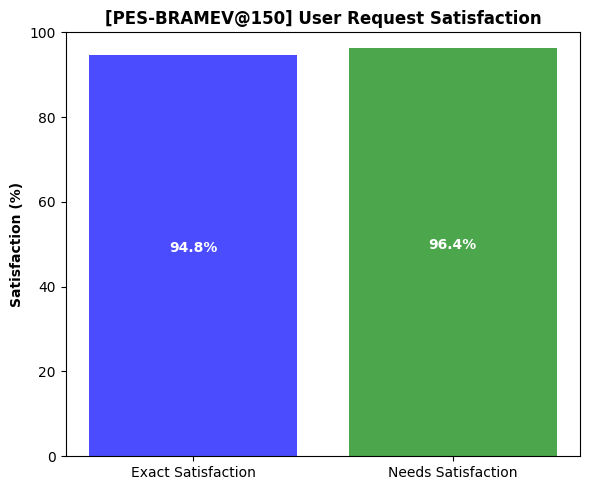

In [87]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

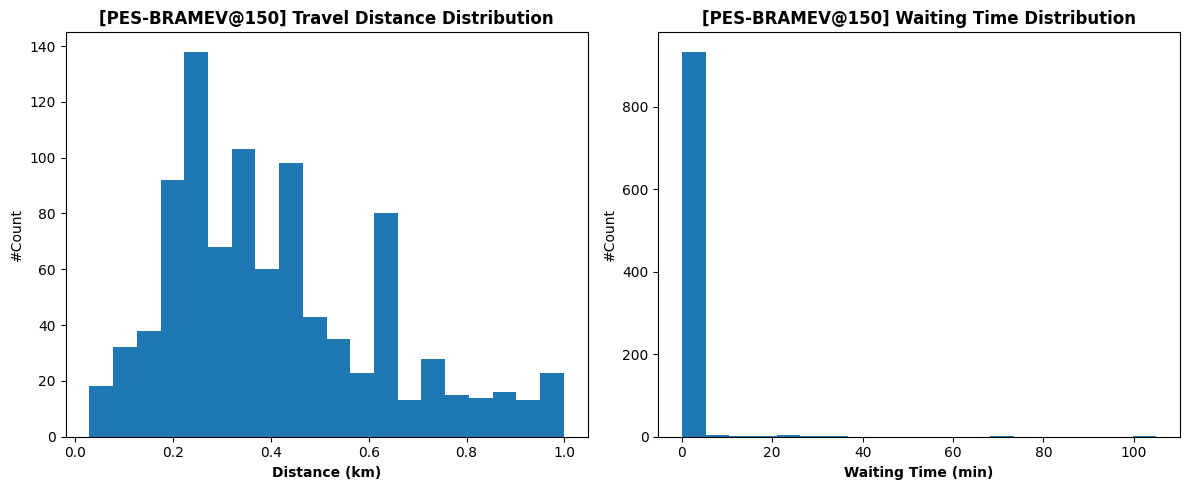

In [88]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

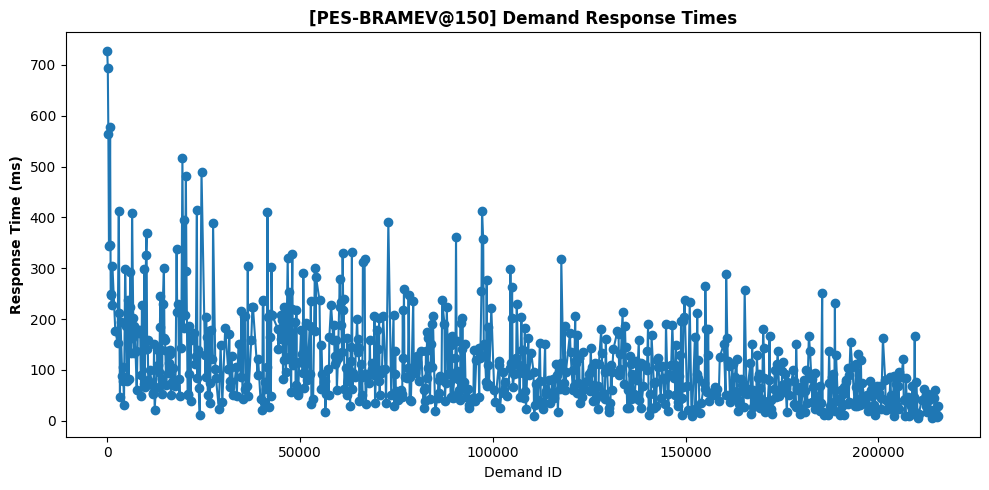

In [89]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

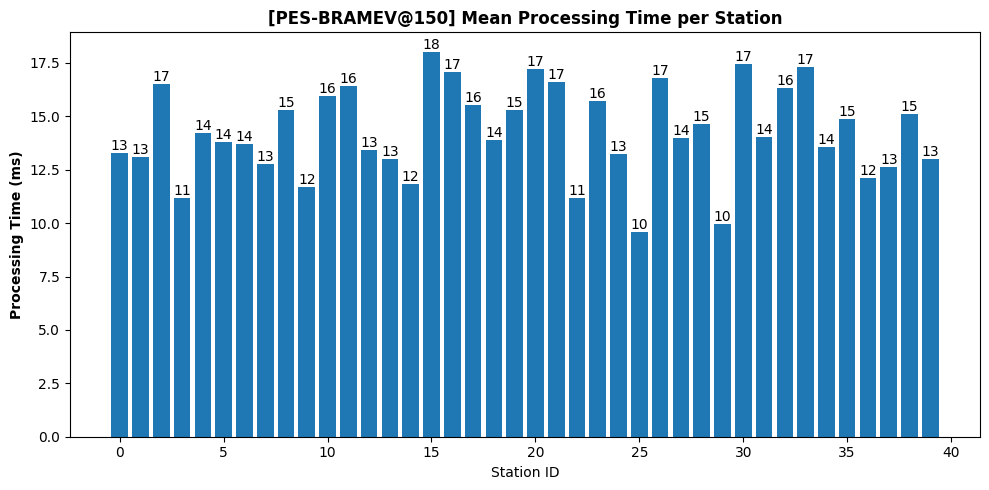

In [90]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [91]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

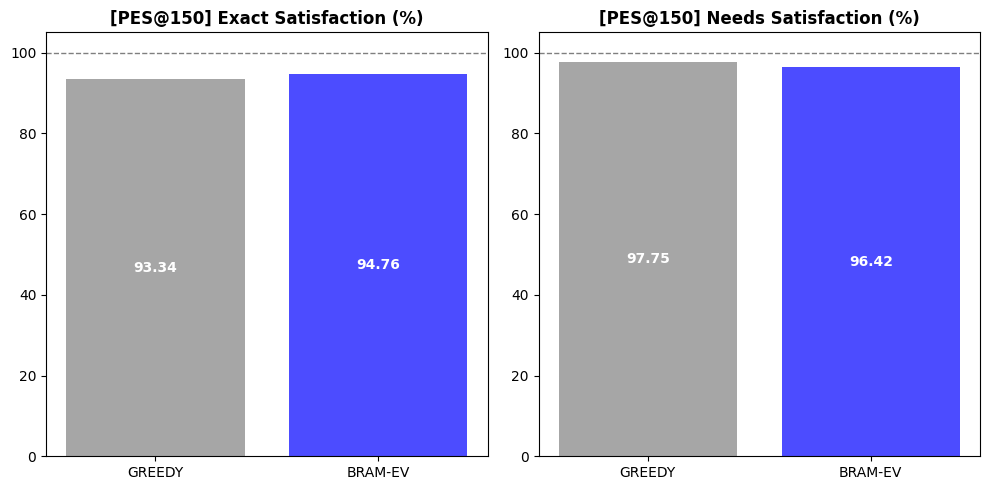

In [92]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

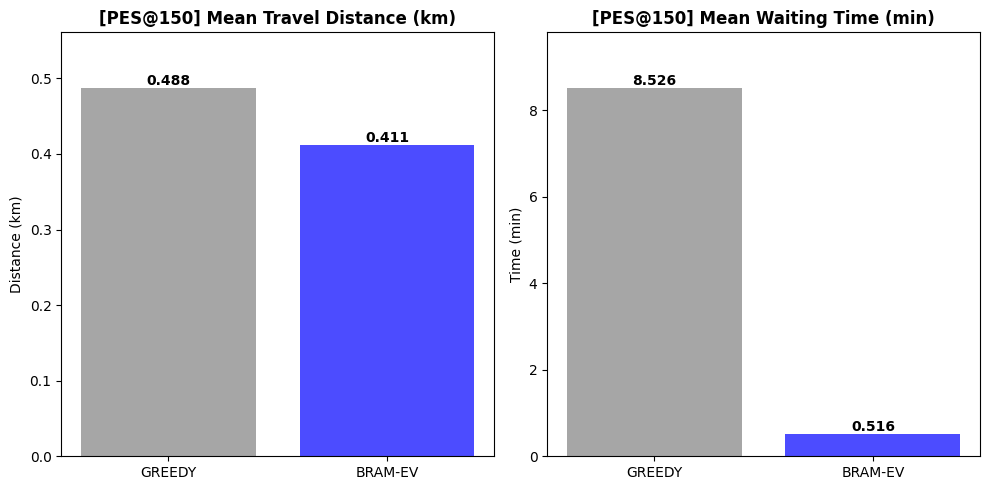

In [93]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

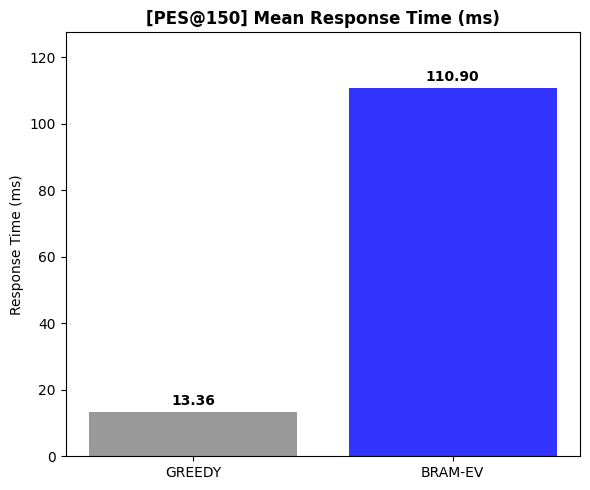

In [94]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@200cars**

#### **CONFIG**

In [95]:
nb_car = 200
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [96]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/pessimistic/greedy/200cars


##### *Initialisation*

In [97]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [98]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-26 00:14:24.458 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-26 00:14:24.707 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-26 00:14:25.081 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-26 00:14:25.242 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-26 00:14:25.502 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-26 00:14:25.764 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-26 00:14:26.051 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-26 00:14:26.186 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-26 00:14:26.378 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-26 00:14:26.554 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-26 00:14:26.861 | IN

##### *Metrics*

In [99]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 3.48 kWh
  Station 1: 45.17 kWh
  Station 2: 43.73 kWh
  Station 3: 114.46 kWh
  Station 4: 7.99 kWh
  Station 5: 1.54 kWh
  Station 6: 33.18 kWh
  Station 7: 54.62 kWh
  Station 8: 12.35 kWh
  Station 9: 3.73 kWh
  Station 10: 6.99 kWh
  Station 11: 43.99 kWh
  Station 12: 230.39 kWh
  Station 13: 4.89 kWh
  Station 14: 234.11 kWh
  Station 15: 265.57 kWh
  Station 16: 6.03 kWh
  Station 17: 34.70 kWh
  Station 18: 84.39 kWh
  Station 19: 9.82 kWh
  Station 20: 1.67 kWh
  Station 21: 3.43 kWh
  Station 22: 65.58 kWh
  Station 23: 15.06 kWh
  Station 24: 64.85 kWh
  Station 25: 6.62 kWh
  Station 26: 13.14 kWh
  Station 27: 45.24 kWh
  Station 28: 57.05 kWh
  Station 29: 9.86 kWh
  Station 30: 10.41 kWh
  Station 31: 305.97 kWh
  Station 32: 107.42 kWh
  Station 33: 22.02 kWh
  Station 34: 16.87 kWh
  Station 35: 56.23 kWh
  Station 36: 18.92 kWh
  Station 37: 54.43 kWh
  Station 38: 31.74 kWh
  Station 39: 5.4

In [100]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

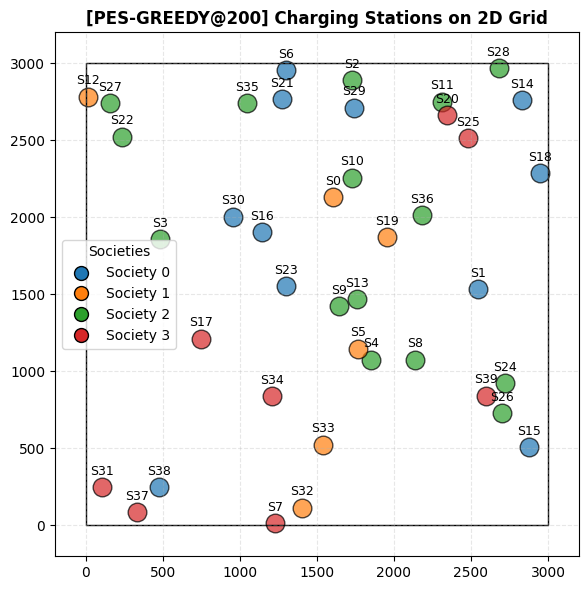

In [101]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

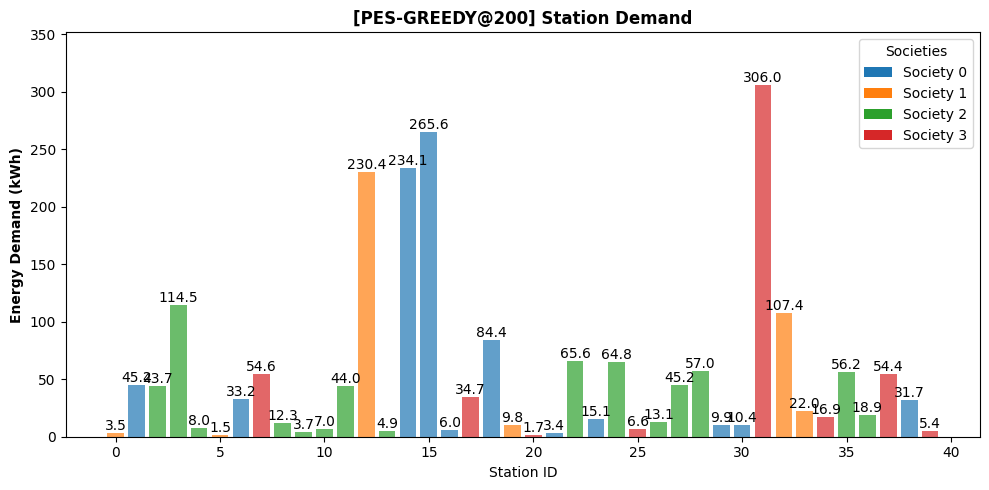

In [102]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

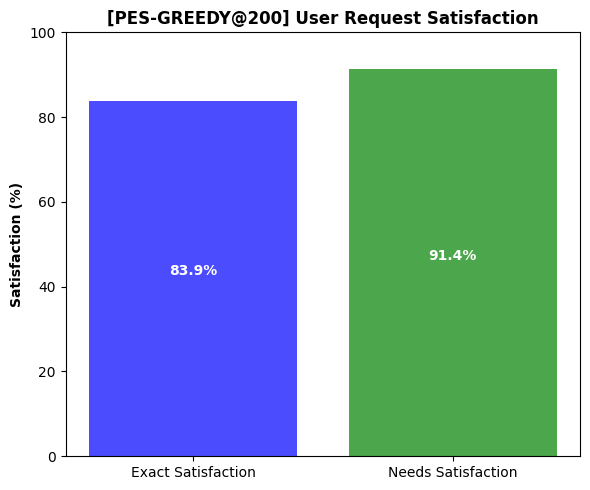

In [103]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

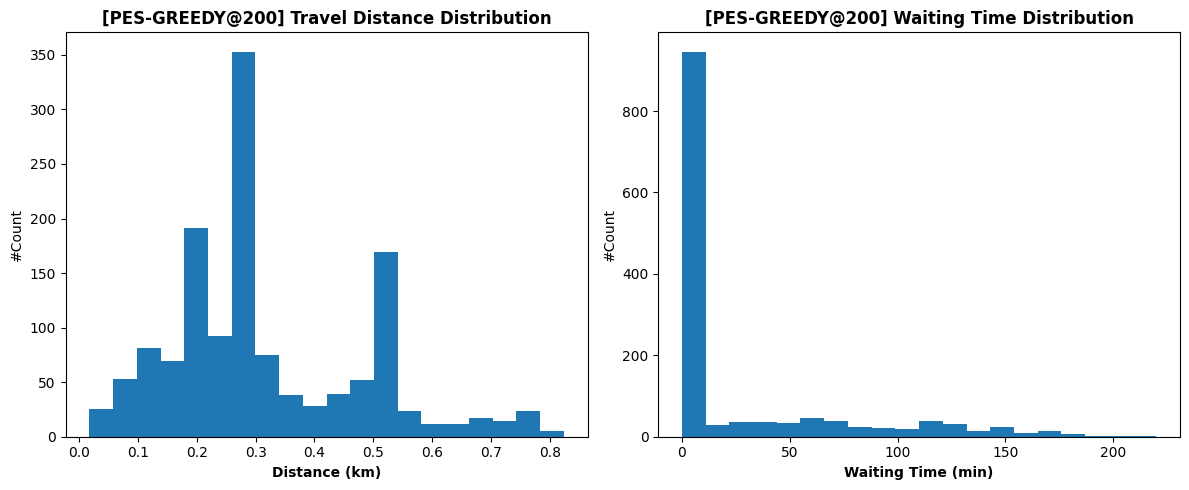

In [104]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

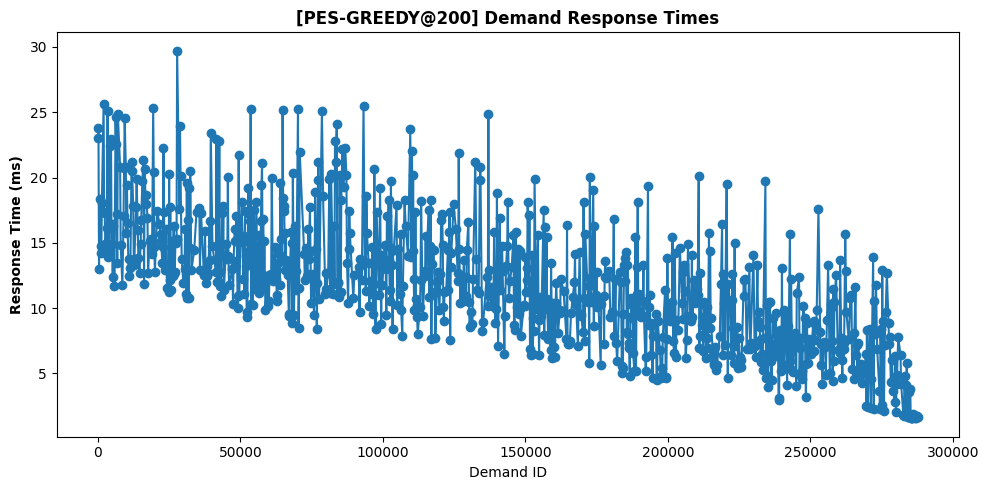

In [105]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

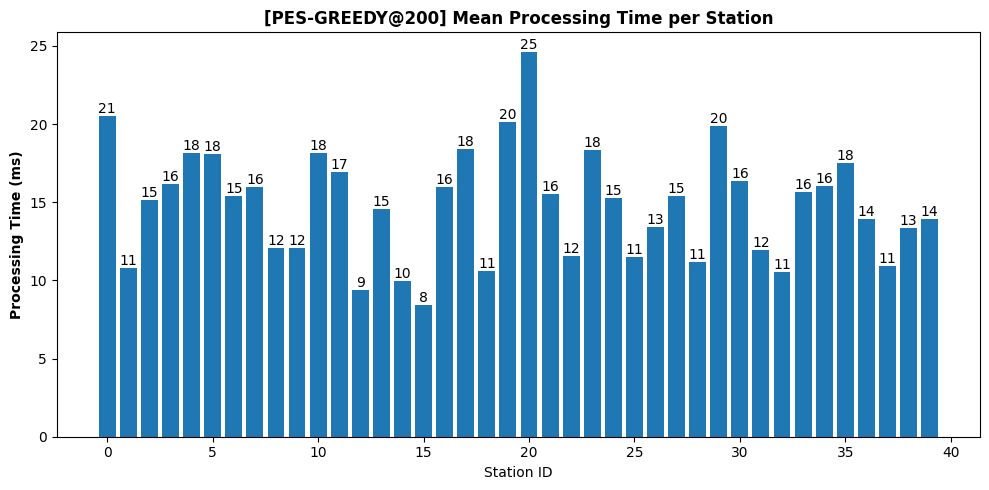

In [106]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [107]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/pessimistic/bramev/200cars


##### *Initialisation*

In [108]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [109]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-26 00:14:50.019 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-26 00:14:54.563 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-26 00:14:56.065 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-26 00:14:58.648 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-26 00:15:01.022 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-26 00:15:04.807 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-26 00:15:08.945 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-26 00:15:10.514 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-26 00:15:13.317 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-26 00:15:15.717 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-26 00:15:18.074 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [110]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 74.82 kWh
  Station 1: 43.81 kWh
  Station 2: 27.32 kWh
  Station 3: 81.67 kWh
  Station 4: 155.13 kWh
  Station 5: 17.29 kWh
  Station 6: 12.94 kWh
  Station 7: 1.80 kWh
  Station 8: 24.42 kWh
  Station 9: 4.16 kWh
  Station 10: 5.08 kWh
  Station 11: 15.38 kWh
  Station 12: 36.50 kWh
  Station 13: 31.26 kWh
  Station 14: 82.44 kWh
  Station 15: 76.17 kWh
  Station 16: 60.80 kWh
  Station 17: 54.63 kWh
  Station 18: 12.13 kWh
  Station 19: 64.47 kWh
  Station 20: 12.54 kWh
  Station 21: 68.83 kWh
  Station 22: 12.56 kWh
  Station 23: 96.17 kWh
  Station 24: 7.90 kWh
  Station 25: 58.04 kWh
  Station 26: 203.18 kWh
  Station 27: 219.13 kWh
  Station 28: 3.75 kWh
  Station 29: 49.14 kWh
  Station 30: 2.07 kWh
  Station 31: 165.37 kWh
  Station 32: 59.02 kWh
  Station 33: 22.75 kWh
  Station 34: 28.39 kWh
  Station 35: 132.61 kWh
  Station 36: 80.56 kWh
  Station 37: 16.87 kWh
  Station 38: 34.27 kWh
  Station 39

In [111]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

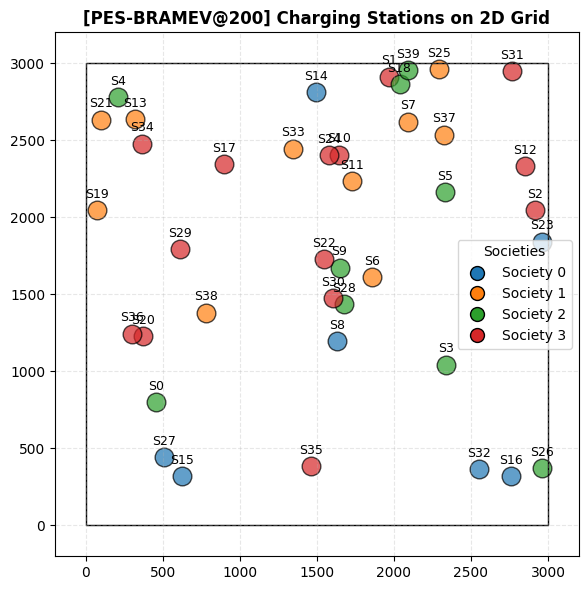

In [112]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

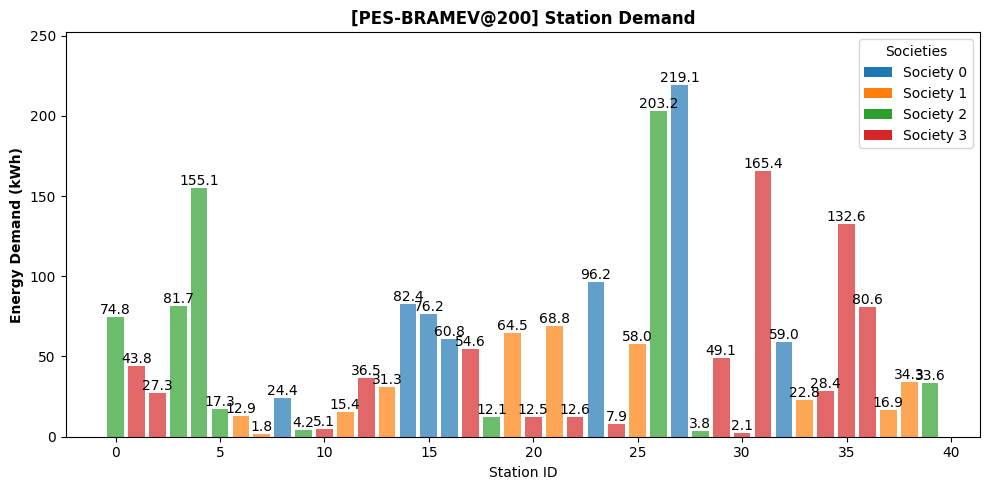

In [113]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

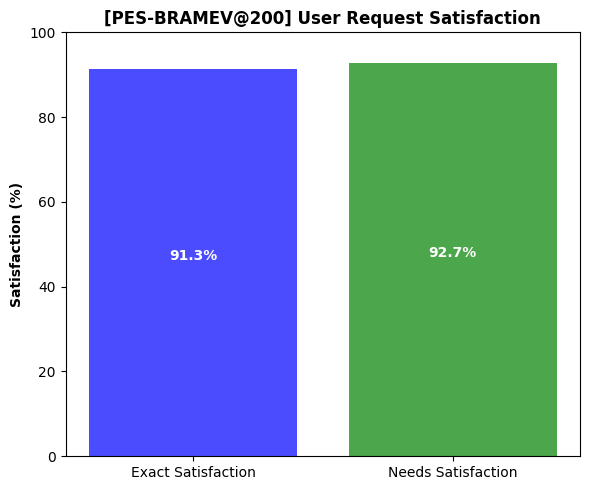

In [114]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

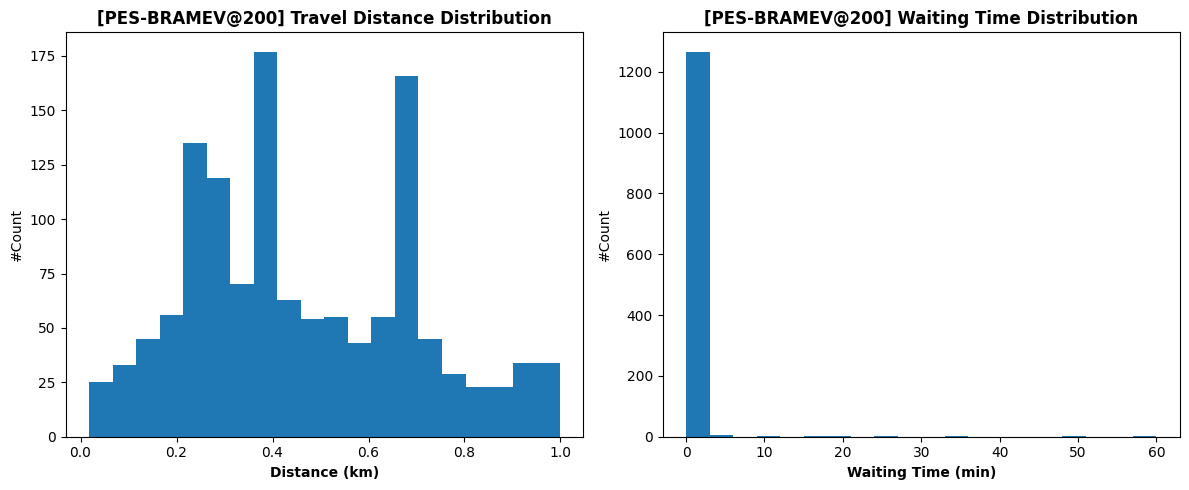

In [115]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

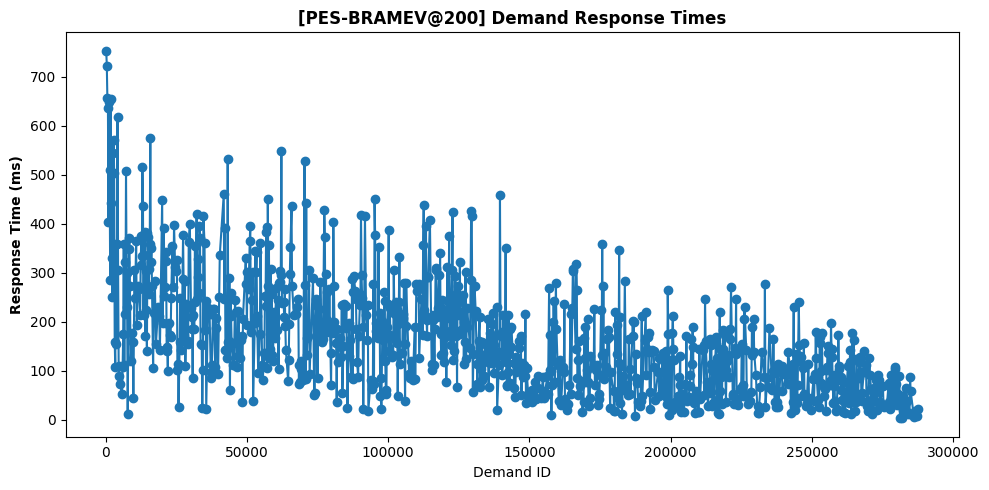

In [116]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

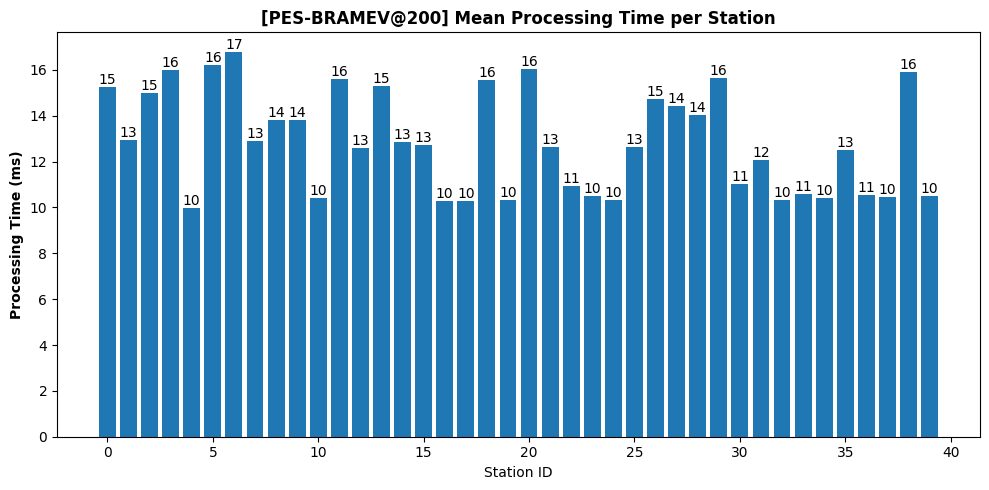

In [117]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [118]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

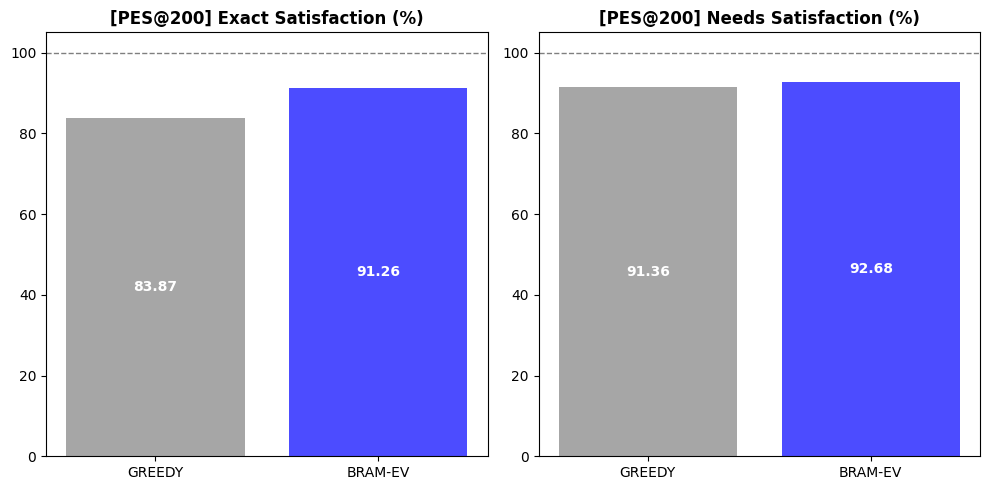

In [119]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

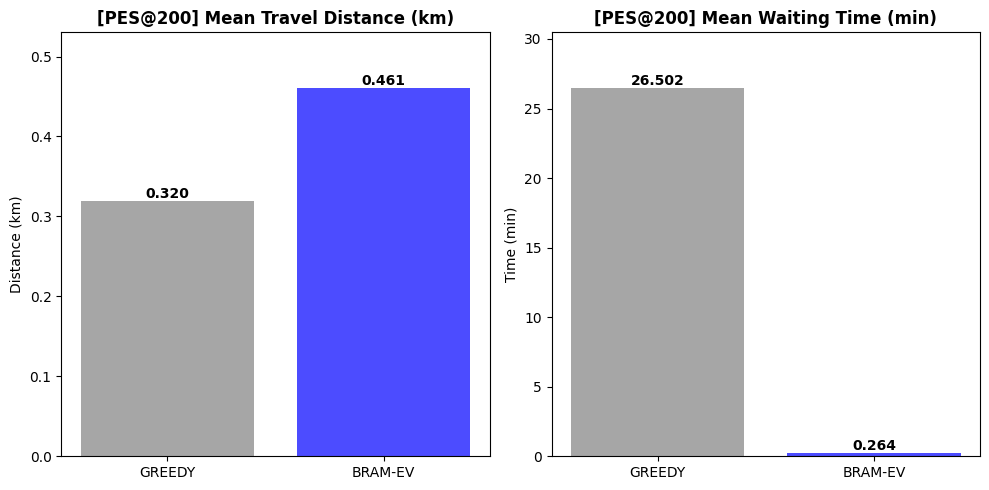

In [120]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

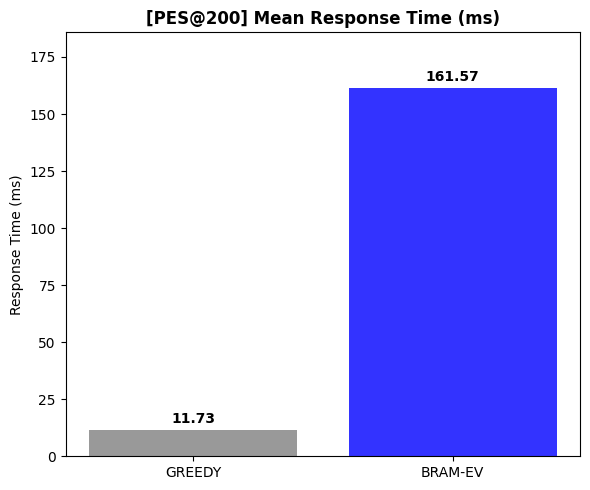

In [121]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@250cars**

#### **CONFIG**

In [122]:
nb_car = 250
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [123]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/pessimistic/greedy/250cars


##### *Initialisation*

In [124]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [125]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-26 00:17:54.628 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-26 00:17:54.860 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-26 00:17:55.249 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-26 00:17:55.564 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-26 00:17:55.820 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-26 00:17:56.049 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-26 00:17:56.393 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-26 00:17:56.756 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-26 00:17:57.150 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-26 00:17:57.389 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-26 00:17:57.662 | IN

##### *Metrics*

In [126]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 148.52 kWh
  Station 1: 126.08 kWh
  Station 2: 1.20 kWh
  Station 3: 145.97 kWh
  Station 4: 7.68 kWh
  Station 5: 0.00 kWh
  Station 6: 19.96 kWh
  Station 7: 14.57 kWh
  Station 8: 3.38 kWh
  Station 9: 23.56 kWh
  Station 10: 107.44 kWh
  Station 11: 8.42 kWh
  Station 12: 1.42 kWh
  Station 13: 116.72 kWh
  Station 14: 277.43 kWh
  Station 15: 12.79 kWh
  Station 16: 5.40 kWh
  Station 17: 18.98 kWh
  Station 18: 0.00 kWh
  Station 19: 137.18 kWh
  Station 20: 32.13 kWh
  Station 21: 55.57 kWh
  Station 22: 69.62 kWh
  Station 23: 295.30 kWh
  Station 24: 23.04 kWh
  Station 25: 131.09 kWh
  Station 26: 20.82 kWh
  Station 27: 71.88 kWh
  Station 28: 30.37 kWh
  Station 29: 4.72 kWh
  Station 30: 22.27 kWh
  Station 31: 1.87 kWh
  Station 32: 66.29 kWh
  Station 33: 31.38 kWh
  Station 34: 271.18 kWh
  Station 35: 6.00 kWh
  Station 36: 73.08 kWh
  Station 37: 292.50 kWh
  Station 38: 9.32 kWh
  Station 39

In [127]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

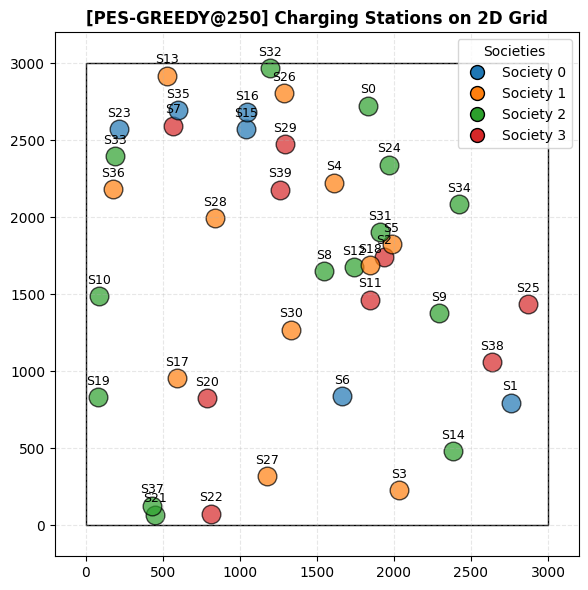

In [128]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

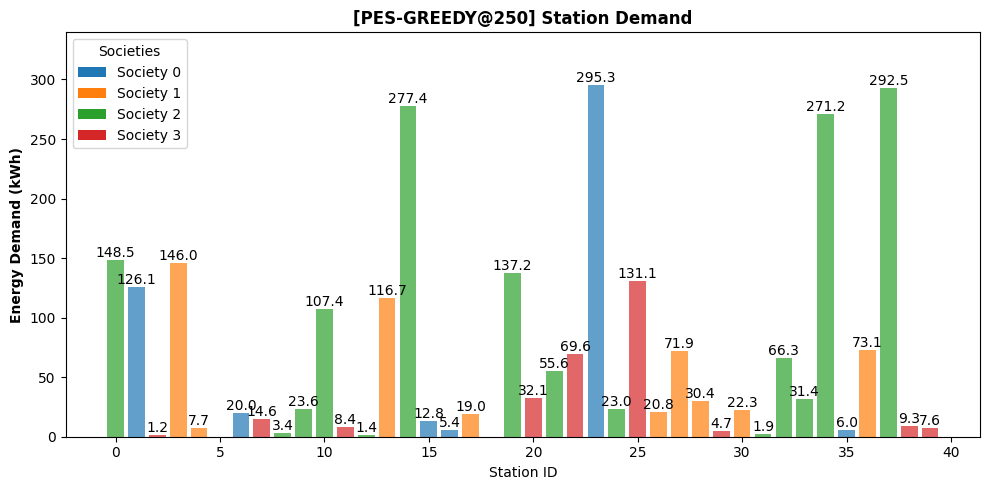

In [129]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

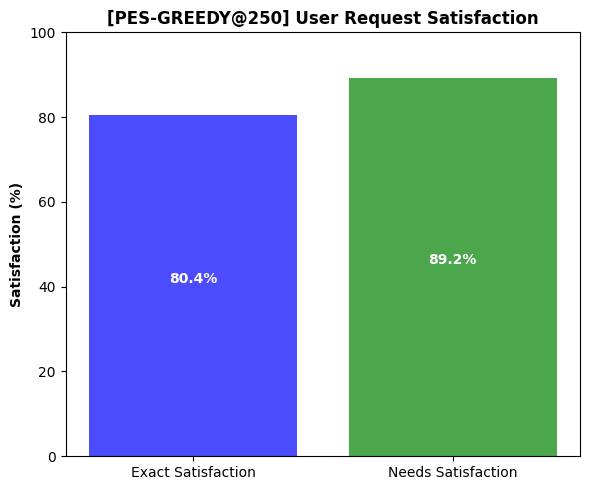

In [130]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

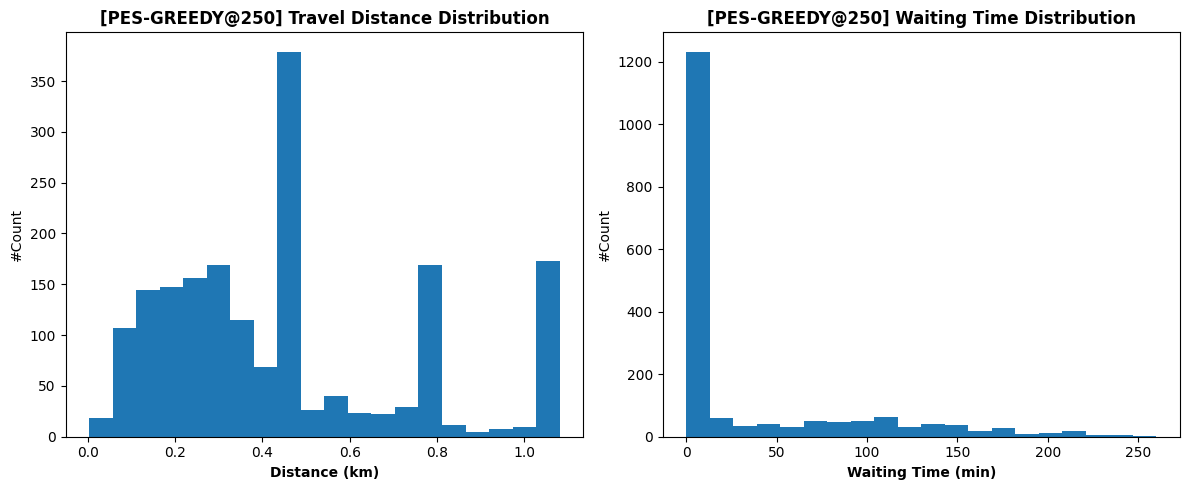

In [131]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

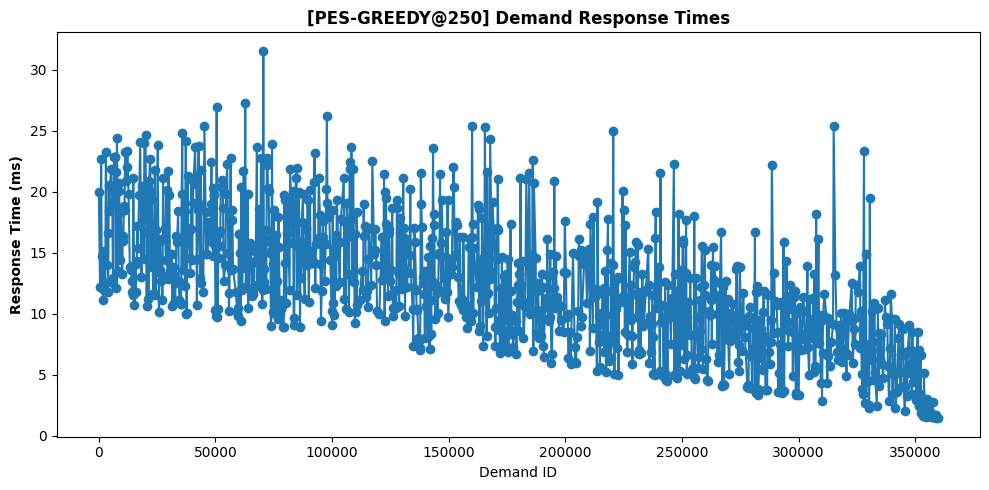

In [132]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

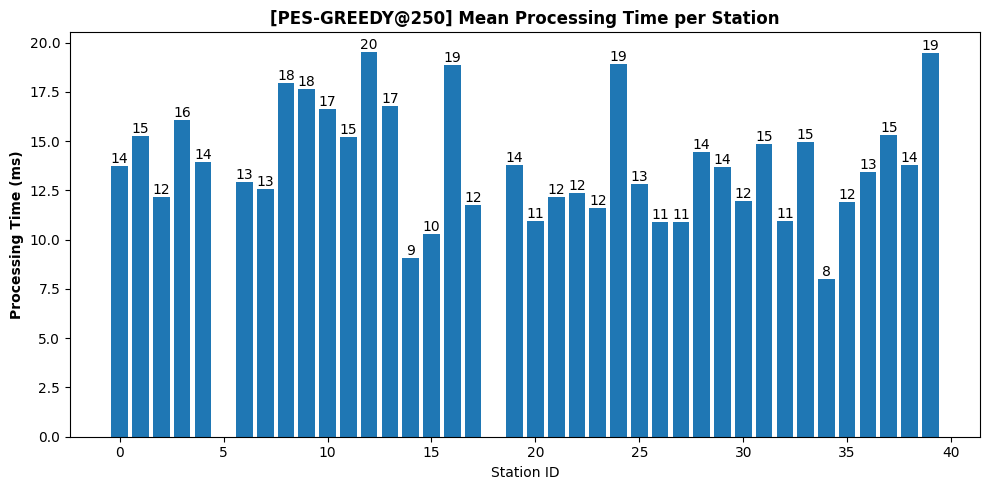

In [133]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [134]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/pessimistic/bramev/250cars


##### *Initialisation*

In [135]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [136]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-26 00:18:28.603 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-26 00:18:38.396 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-26 00:18:47.645 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-26 00:18:56.098 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-26 00:19:04.952 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-26 00:19:12.938 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-26 00:19:21.115 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-26 00:19:27.992 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-26 00:19:33.230 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-26 00:19:35.646 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-26 00:19:38.327 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [137]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 33.36 kWh
  Station 1: 26.01 kWh
  Station 2: 103.74 kWh
  Station 3: 185.38 kWh
  Station 4: 36.52 kWh
  Station 5: 42.54 kWh
  Station 6: 22.15 kWh
  Station 7: 23.43 kWh
  Station 8: 38.14 kWh
  Station 9: 38.08 kWh
  Station 10: 33.64 kWh
  Station 11: 140.07 kWh
  Station 12: 192.36 kWh
  Station 13: 31.55 kWh
  Station 14: 19.81 kWh
  Station 15: 209.04 kWh
  Station 16: 21.98 kWh
  Station 17: 6.88 kWh
  Station 18: 34.81 kWh
  Station 19: 9.23 kWh
  Station 20: 144.61 kWh
  Station 21: 42.80 kWh
  Station 22: 103.67 kWh
  Station 23: 172.10 kWh
  Station 24: 91.30 kWh
  Station 25: 96.17 kWh
  Station 26: 21.23 kWh
  Station 27: 64.99 kWh
  Station 28: 36.65 kWh
  Station 29: 137.97 kWh
  Station 30: 52.30 kWh
  Station 31: 16.23 kWh
  Station 32: 99.08 kWh
  Station 33: 49.77 kWh
  Station 34: 14.40 kWh
  Station 35: 41.27 kWh
  Station 36: 102.03 kWh
  Station 37: 109.07 kWh
  Station 38: 31.02 kWh
  

In [138]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

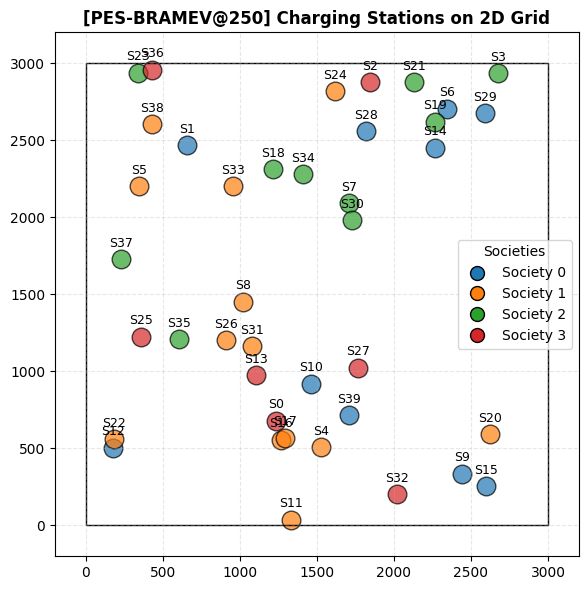

In [139]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

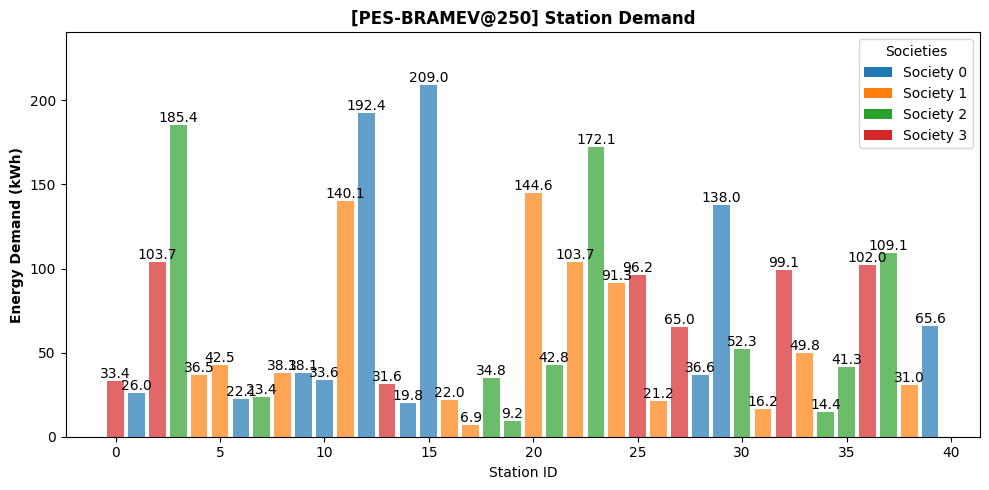

In [140]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

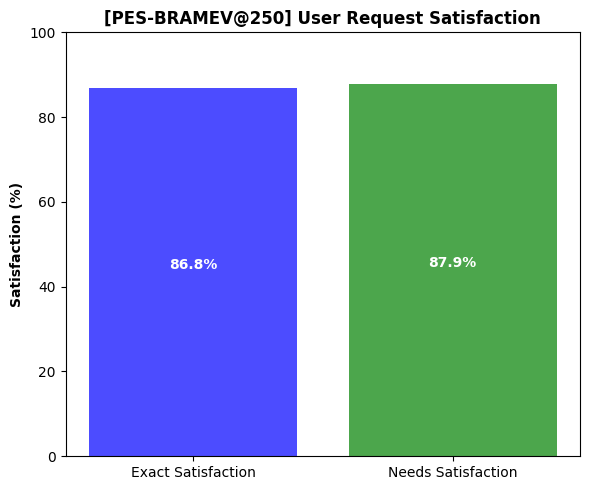

In [141]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

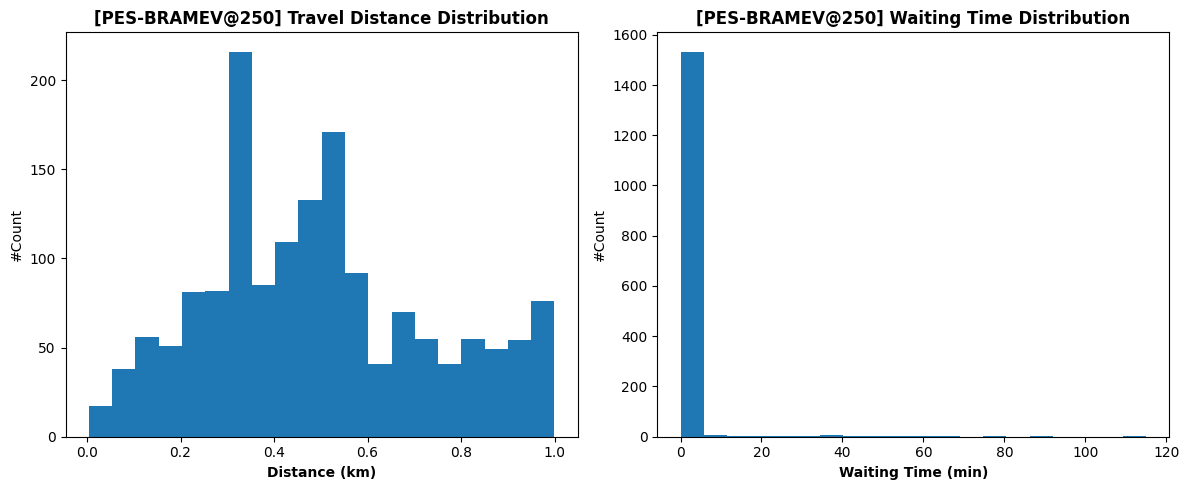

In [142]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

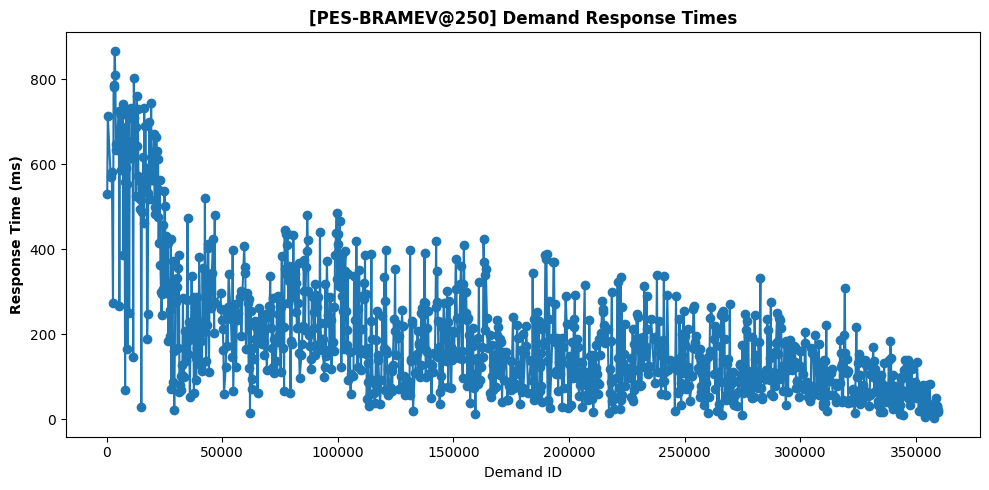

In [143]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

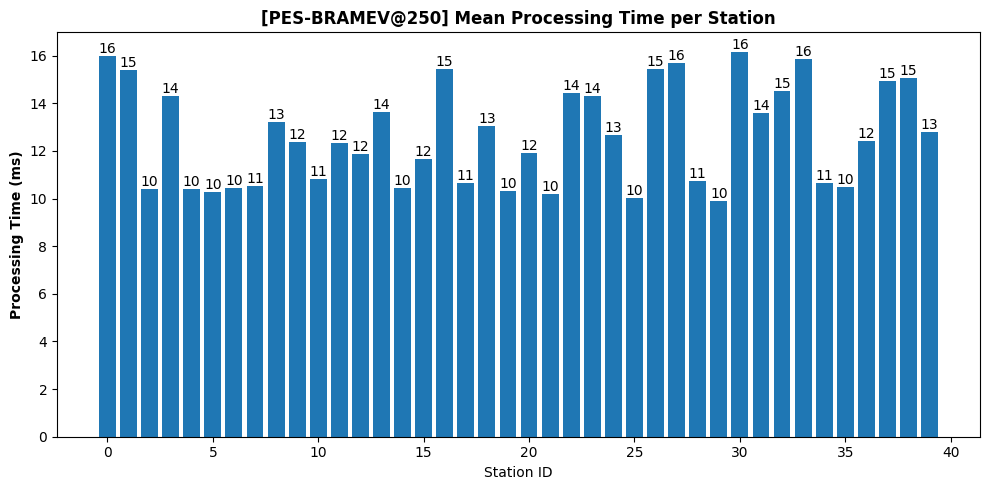

In [144]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [145]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

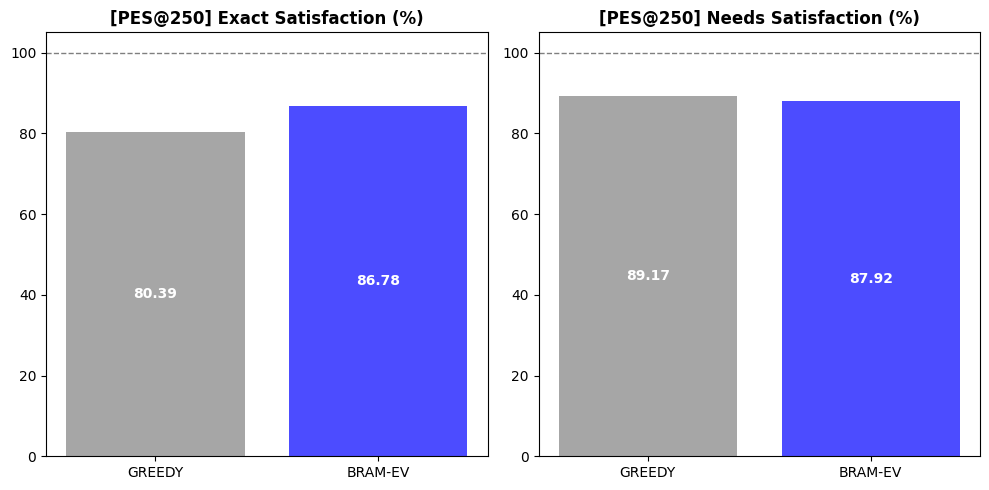

In [146]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

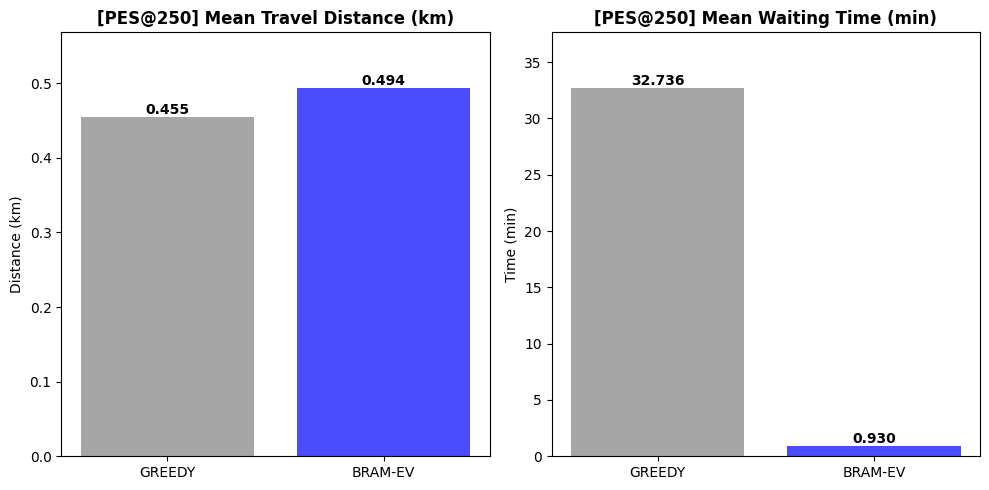

In [147]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

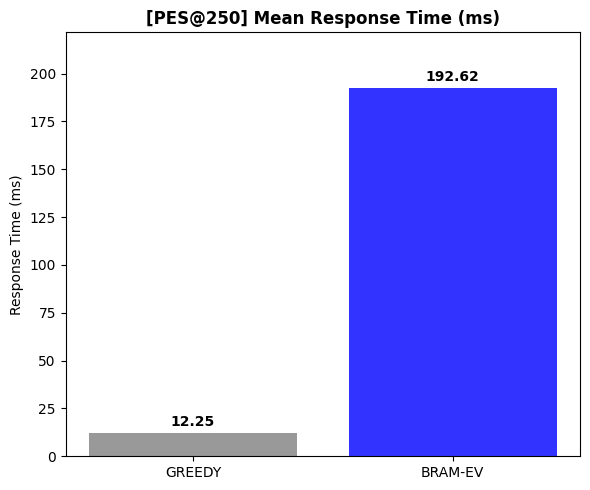

In [148]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

## **COMPARISON**

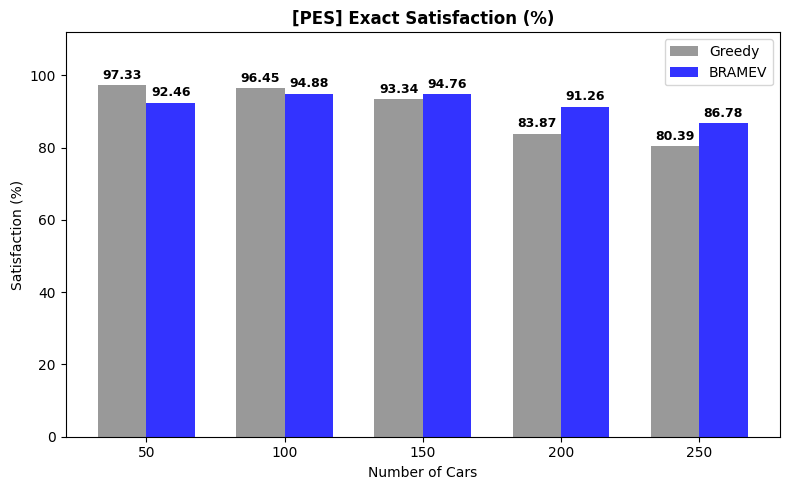

In [149]:
plot_exact_satisfaction(
    exact_satif_greedy_list,
    exact_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

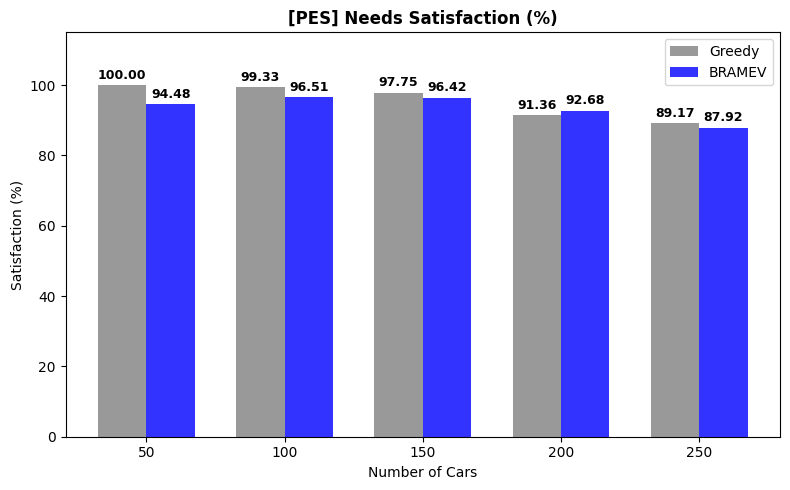

In [150]:
plot_needs_satisfaction(
    needs_satif_greedy_list,
    needs_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

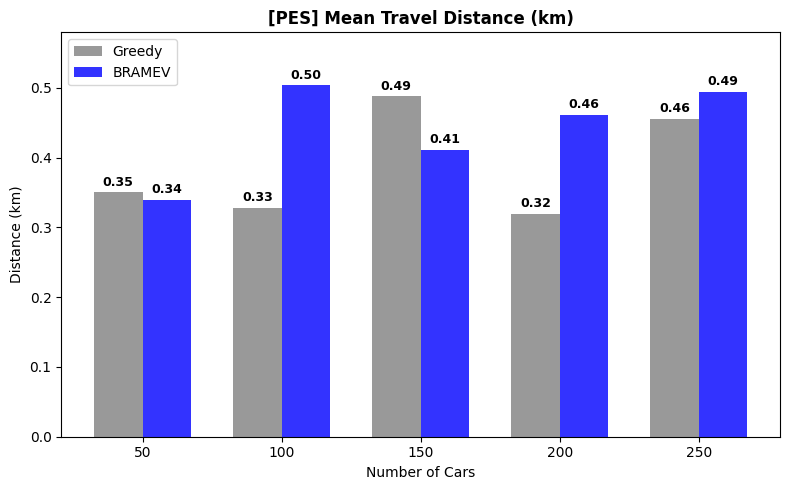

In [151]:
plot_mean_travel_distance(
    mean_travel_greedy_list,
    mean_travel_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


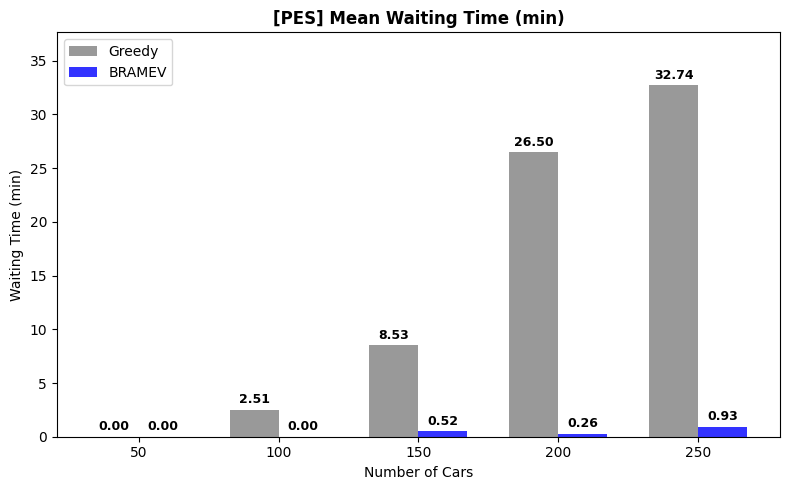

In [152]:
plot_mean_waiting_time(
    mean_waiting_greedy_list,
    mean_waiting_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


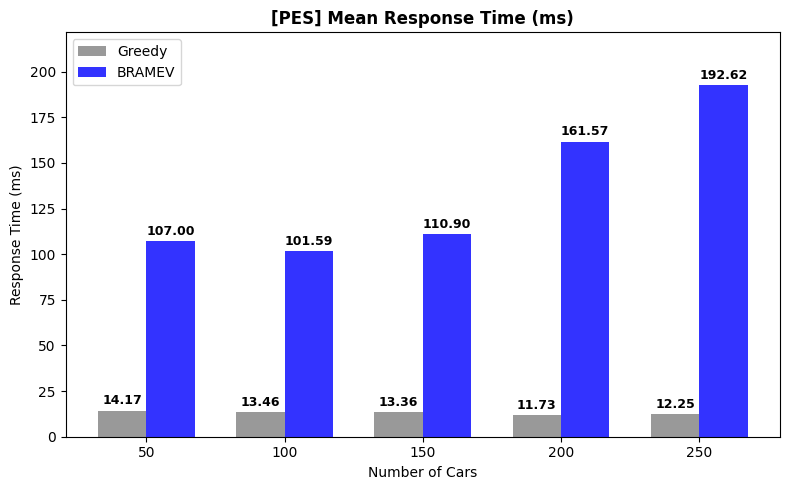

In [153]:
plot_mean_response_time(
    mean_response_greedy_list,
    mean_response_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)
